In [39]:
import pandas as pd
"from langchain_ollama import OllamaLLM\n",
    "from pandas.core.interchange.dataframe_protocol import DataFrame\n",
    "from pandas.plotting import plot_params\n",
    "\n",
    "llm = OllamaLLM(model=\"llama3.2:latest\", temperature=0.4, top_k=99)\n",
    "prompt = \"Who was the first person to walk on moon?\"\n",
    "response = llm.invoke(prompt)\n",
    "print(response)"

"from langchain_community.tools import TavilySearchResults\n",
    "from dotenv import load_dotenv\n",
    "load_dotenv()\n",
    "\n",
    "from typing import Annotated\n",
    "from typing_extensions import TypedDict\n",
    "\n",
    "from langgraph.graph.message import add_messages\n",
    "from langchain_core.tools import tool\n",
    "from langchain_ollama import ChatOllama\n",
    "\n",
    "class State(TypedDict):\n",
    "    # Messages have the type \"list\". The `add_messages` function in the\n",
    "    # annotation defines how this state key should be updated\n",
    "    messages:Annotated[list, add_messages]\n",
    "\n",
    "## Custom function\n",
    "@tool\n",
    "def multiply(a:int, b:int) -> int:\n",
    "    \"\"\"\n",
    "    Multiplies two numbers\n",
    "    :param a: int a\n",
    "    :param b: int b\n",
    "    :return: a multiplied by b\n",
    "    \"\"\"\n",
    "    return a * b\n",
    "\n",
    "@tool\n",
    "def internet_search(query: str):\n",
    "    \"\"\"\n",
    "    Search the web for realtime and latest information.\n",
    "    for examples, news, stock market, weather updates etc.\n",
    "\n",
    "    Args:\n",
    "    query: The search query\n",
    "    \"\"\"\n",
    "    search = TavilySearchResults(\n",
    "        max_results=2,\n",
    "        search_depth='advanced',\n",
    "        include_answer=True,\n",
    "        include_raw_content=True,\n",
    "    )\n",
    "    response = search.invoke(query)\n",
    "    return response\n",
    "\n",
    "@tool\n",
    "def llm_search(query: str):\n",
    "    \"\"\"\n",
    "    Use the LLM model for general and basic information.\n",
    "    \"\"\"\n",
    "    response = llm.invoke(query)\n",
    "    return response\n",
    "\n",
    "@tool\n",
    "def fetch_portfolio_from_broker():\n",
    "    \"\"\"\n",
    "    Fetch portfolio from broker\n",
    "    :return: portfolio\n",
    "    \"\"\"\n",
    "    return smartApi.holding()\n",
    "\n",
    "@tool\n",
    "def fetch_data_from_broker(symbol, interval, start_date, end_date):\n",
    "    \"\"\"\n",
    "    :param symbol: stock symbol in format `NSE:{symbol}-EQ`\n",
    "    :param interval: FIVE_MINUTE, ONE_HOUR, ONE_DAY etc\n",
    "    :param start_date: str in '%Y-%m-%d %H:%M' format. start date should be before the end date by 1 day for intraday data.\n",
    "    :param end_date: str in '%Y-%m-%d %H:%M' format\n",
    "    :return: 2D array with timestamp, open, high, low, close, volume\n",
    "\n",
    "    ## Fetch data usage example\n",
    "    end_date = datetime(2025, 10, 24, 0, 0)\n",
    "    start_date = date_obj-pd.DateOffset(days=1)\n",
    "    fetch_hdata_from(exchange='NSE',\n",
    "                     symboltoken=token_fetcher.get_symbol_token('NSE:TCS-EQ'),\n",
    "                     start=convert_date_to_string(start_date),\n",
    "                     end=convert_date_to_string(end_date),\n",
    "                     interval=\"FIVE_MINUTE\")\n",
    "    \"\"\"\n",
    "    d=smartApi.getCandleData({\n",
    "    \"exchange\": 'NSE',\n",
    "    \"symboltoken\": token_fetcher.get_symbol_token(symbol),\n",
    "    \"interval\": interval,\n",
    "    \"fromdate\": start_date,\n",
    "    \"todate\": end_date\n",
    "    })['data']\n",
    "    return add_new_high_low_indicators(d)\n",
    "\n",
    "@tool\n",
    "def add_high_low_indicators(data):\n",
    "    \"\"\"\n",
    "\n",
    "    :param data: stock OHLC 2D array data with timestamp, OHLCV data\n",
    "    :return: enriched data with new high and low indicators\n",
    "    \"\"\"\n",
    "    \"\"\"\n",
    "        * ``new_high`` (bool) – True if this row is the highest seen so far.\n",
    "        * ``new_low`` (bool) – True if this row is the lowest seen so far.\n",
    "        * ``cumulative_high`` (float) – Highest value seen so far.\n",
    "        * ``cumulative_low`` (float) – Lowest value seen so far.\n",
    "        * ``range`` (float) – Difference between cumulative high and low.\n",
    "        * ``range_percent`` (float) – Range expressed as a % of the first close.\n",
    "        * ``high_drawdown`` (float) – Drawdown ratio from the cumulative high to the current close,\n",
    "          expressed in absolute units.\n",
    "        * ``low_drawdown`` (float) – Drawdown ratio from the cumulative low to the current close.\n",
    "    \"\"\"\n",
    "    return add_new_high_low_indicators(data)\n",
    "    # highest = data[0]['high']\n",
    "    # lowest = data[0]['low']\n",
    "    # close = data[0]['close']\n",
    "    # for entry in data:\n",
    "    #     close = entry['close']\n",
    "    #     highest = max(highest, entry['high'])\n",
    "    #     lowest = min(lowest, entry['low'])\n",
    "    #     range = highest - lowest\n",
    "    #     range_percent = range / data[0][0] * 100\n",
    "    #     high_drawdown = abs(highest - close) * range_percent\n",
    "    #     low_drawdown = abs(lowest - close) * range_percent\n",
    "    #\n",
    "    #     data['new_high'] = highest == entry['high']\n",
    "    #     data['new_low'] = lowest == entry['low']\n",
    "    #     data['highest'] = highest\n",
    "    #     data['lowest'] = lowest\n",
    "    #     data['range_percent'] = range_percent\n",
    "    #     data['range'] = range\n",
    "    #     data['high_drawdown'] = high_drawdown\n",
    "    #     data['low_drawdown'] = low_drawdown\n",
    "\n",
    "llm = ChatOllama(\n",
    "    model=\"gpt-oss:latest\",\n",
    "    validate_model_on_init=True,\n",
    "    temperature=0\n",
    ")\n",
    "# llm = ChatGroq(model=\"llama3-8b-8192\")\n",
    "tools = [multiply, add_high_low_indicators, fetch_data_from_broker, fetch_portfolio_from_broker]\n",
    "llm_with_tools = llm.bind_tools(tools)\n",
    "\n",
    "from langgraph.graph import StateGraph, START, END\n",
    "from langgraph.prebuilt import ToolNode\n",
    "from langgraph.prebuilt import tools_condition\n",
    "\n",
    "## Node definition\n",
    "def tool_calling_llm(state: State):\n",
    "    return {\"messages\":[llm_with_tools.invoke(state[\"messages\"])]}\n",
    "\n",
    "## Graph\n",
    "builder=StateGraph(State)\n",
    "builder.add_node(\"tool_calling_llm\", tool_calling_llm)\n",
    "builder.add_node(\"tools\", ToolNode(tools))\n",
    "\n",
    "## Add Edges\n",
    "builder.add_edge(START, \"tool_calling_llm\")\n",
    "builder.add_conditional_edges(\n",
    "    \"tool_calling_llm\", tools_condition\n",
    ")\n",
    "builder.add_edge(\"tools\", \"tool_calling_llm\")\n",
    "builder.add_edge(\"tool_calling_llm\", END)\n",
    "\n",
    "## Compile the graph\n",
    "graph=builder.compile()\n",
    "\n",
    "from IPython.display import Image, display\n",
    "display(Image(graph.get_graph().draw_mermaid_png()))\n",
    "\n",
    "# llm.invoke(\"What is 4 multiplied by 8\")\n"
   ]
  },

IndentationError: unindent does not match any outer indentation level (<string>, line 176)

In [ ]:
"response=graph.invoke({\"messages\":\"What is portfolio performance today for my account\"})\n",
    "for message in response[\"messages\"]:\n",
    "    message.pretty_print()\n",
    "# response[\"messages\"][-1].content"

"response=graph.invoke({\"messages\":high_low_prompt})\n",
    "for message in response[\"messages\"]:\n",
    "    message.pretty_print()"

"import pandas as pd\n",
    "def load_symbol_master(file_path):\n",
    "    \"\"\"Loads symbol master data from JSON file\"\"\"\n",
    "    return pd.read_json(file_path).T.reset_index()\n",
    "\n",
    "class TokenFetcher:\n",
    "    def __init__(self, symbol_master_df):\n",
    "        \"\"\"\n",
    "        Initializes the token fetcher with a symbol master DataFrame.\n",
    "\n",
    "        :param symbol_master_df: The loaded symbol master DataFrame\n",
    "        \"\"\"\n",
    "        self.symbol_master_df = symbol_master_df\n",
    "\n",
    "    def get_symbol_token(self, sym_ticker):\n",
    "        \"\"\"\n",
    "        Fetches the exToken for a given symbol ticker.\n",
    "\n",
    "        :param sym_ticker: The symbol ticker to fetch the token for\n",
    "        :return: The fetched token or None if an error occurs\n",
    "        \"\"\"\n",
    "        try:\n",
    "            return self.symbol_master_df.loc[self.symbol_master_df['symTicker'] == sym_ticker, 'exToken'].iloc[0]\n",
    "        except Exception as e:\n",
    "            print(f\"Error fetching symbol token: {e}\")\n",
    "            return None\n",
    "\n",
    "    def get_symbol_token_list(self, stocks_list):\n",
    "        \"\"\"\n",
    "        Fetches the exTokens for a list of stock tickers.\n",
    "\n",
    "        :param stocks_list: A list of stock tickers to fetch tokens for\n",
    "        :return: A dictionary mapping each stock ticker to its corresponding token\n",
    "        \"\"\"\n",
    "        symbol_token_list = {}\n",
    "        for stock in stocks_list:\n",
    "            symbol_token_list[stock] = self.get_symbol_token(stock)\n",
    "        return symbol_token_list\n",
    "\n",
    "## Initialize symbol token fetcher\n",
    "symbol_master_df = load_symbol_master('/Users/praprsa/Documents/NSE_CM_sym_master.json')\n",
    "token_fetcher = TokenFetcher(symbol_master_df)\n",
    "\n",
    "print(token_fetcher.get_symbol_token('NSE:TCS-EQ'))\n",
    "token_fetcher.get_symbol_token_list(['NSE:TCS-EQ'])"

In [ ]:
"from SmartApi import SmartConnect\n",
    "import pyotp\n",
    "from logzero import logger\n",
    "from time import sleep\n",
    "from datetime import datetime\n",
    "\n",
    "api_key = 'xbNanBzM'\n",
    "smartApi = SmartConnect(api_key)\n",
    "def brokerLogin():\n",
    "    username = 'G192004'\n",
    "    pwd = '7284'\n",
    "\n",
    "    try:\n",
    "        token = \"O6S6PODP2KLWYNUCRQHLJZK7OI\"\n",
    "        totp = pyotp.TOTP(token).now()\n",
    "    except Exception as e:\n",
    "        logger.error(\"Invalid Token: The provided token is not valid.\")\n",
    "        raise e\n",
    "\n",
    "    smartApi.generateSession(username, pwd, totp)\n",
    "    return 'Login Successful!'\n",
    "\n",
    "def convert_date_to_string(date_obj):\n",
    "    return date_obj.strftime('%Y-%m-%d %H:%M')\n",
    "\n",
    "def fetch_hdata_from(exchange, symboltoken, start, end, interval=\"ONE_DAY\"):\n",
    "    try:\n",
    "        historicParam={\n",
    "        \"exchange\": exchange,\n",
    "        \"symboltoken\": symboltoken,\n",
    "        \"interval\": interval,\n",
    "        \"fromdate\": start,\n",
    "        \"todate\": end\n",
    "        }\n",
    "        d = smartApi.getCandleData(historicParam)\n",
    "        # logger.info(d)\n",
    "        sleep(0.2)\n",
    "        return d['data']\n",
    "    except Exception as e:\n",
    "        logger.exception(f\"Historic Api failed: {e}\")"
    "brokerLogin()"


In [ ]:
"## Fetch data usage from broker\n",
    "end_date = datetime(2025, 10, 31, 0, 0)\n",
    "start_date = end_date-pd.DateOffset(days=1)\n",
    "data=fetch_hdata_from(exchange='NSE',\n",
    "                 symboltoken=token_fetcher.get_symbol_token('NSE:OIL-EQ'),\n",
    "                 start=convert_date_to_string(start_date),\n",
    "                 end=convert_date_to_string(end_date),\n",
    "                 interval=\"FIVE_MINUTE\")"

"def fetch_intraday_data(symbol) -> pd.DataFrame:\n",
    "    exchange = 'NSE'\n",
    "    start = datetime(2025, 10, 30, 0, 0)\n",
    "    end = start+pd.DateOffset(days=1)\n",
    "    return add_new_high_low_indicators(\n",
    "        fetch_hdata_from(exchange=exchange,\n",
    "            symboltoken=token_fetcher.get_symbol_token(f\"{exchange}:{symbol}-EQ\"),\n",
    "            start=convert_date_to_string(start), end=convert_date_to_string(end), interval=\"FIVE_MINUTE\"))\n",
    "\n",
    "def add_new_high_low_indicators(data) -> pd.DataFrame:\n",
    "    \"\"\"\n",
    "    Enrich OHLCV data with new‑high / new‑low indicators.\n",
    "\n",
    "    Parameters\n",
    "    ----------\n",
    "    data : 2D array consisting of timestamp, OHLCV data.\n",
    "\n",
    "    Returns\n",
    "    -------\n",
    "    pd.DataFrame\n",
    "        New DataFrame with the original columns plus the following:\n",
    "\n",
    "        * ``new_high`` (bool) – True if this row is the highest seen so far.\n",
    "        * ``new_low`` (bool) – True if this row is the lowest seen so far.\n",
    "        * ``cumulative_high`` (float) – Highest value seen so far.\n",
    "        * ``cumulative_low`` (float) – Lowest value seen so far.\n",
    "        * ``range`` (float) – Difference between cumulative high and low.\n",
    "        * ``range_percent`` (float) – Range expressed as a % of the first close.\n",
    "        * ``high_drawdown`` (float) – Drawdown ratio from the cumulative high to the current close,\n",
    "          expressed in absolute units.\n",
    "        * ``low_drawdown`` (float) – Drawdown ratio from the cumulative low to the current close.\n",
    "\n",
    "    Notes\n",
    "    -----\n",
    "    The function never mutates the input.  All calculations are vectorised\n",
    "    for performance.\n",
    "    \"\"\"\n",
    "\n",
    "    cols = [\"timestamp\", \"open\", \"high\", \"low\", \"close\", \"volume\"]\n",
    "    df=pd.DataFrame([dict(zip(cols, row)) for row in data])\n",
    "    # ----------------------------------------------------------------------- #\n",
    "    # Compute cumulative high/low\n",
    "    # ----------------------------------------------------------------------- #\n",
    "    df[\"cumulative_high\"] = df[\"high\"].cummax()\n",
    "    df[\"cumulative_low\"] = df[\"low\"].cummin()\n",
    "\n",
    "    # ----------------------------------------------------------------------- #\n",
    "    # Flags for new high / low\n",
    "    # ----------------------------------------------------------------------- #\n",
    "    df[\"new_high\"] = df[\"high\"] == df[\"cumulative_high\"]\n",
    "    df[\"new_low\"] = df[\"low\"] == df[\"cumulative_low\"]\n",
    "\n",
    "    # ----------------------------------------------------------------------- #\n",
    "    # Range and range percent\n",
    "    # ----------------------------------------------------------------------- #\n",
    "    df[\"range\"] = df[\"cumulative_high\"] - df[\"cumulative_low\"]\n",
    "    # Use the first close as the reference point for the percent\n",
    "    first_close = df[\"close\"].iloc[0]\n",
    "    first_open = df[\"open\"].iloc[0]\n",
    "    if first_close == 0:\n",
    "        # Avoid division by zero – set to NaN and warn\n",
    "        df[\"range_percent\"] = pd.NA\n",
    "    else:\n",
    "        df[\"range_percent\"] = (df[\"range\"] / first_close) * 100\n",
    "\n",
    "    # ----------------------------------------------------------------------- #\n",
    "    # Drawdowns\n",
    "    # ----------------------------------------------------------------------- #\n",
    "    df[\"high_drawdown\"] = 100*(abs(df[\"cumulative_high\"] - df[\"close\"])) / df[\"range\"]\n",
    "    df[\"low_drawdown\"] = 100*(abs(df[\"cumulative_low\"] - df[\"close\"])) / df[\"range\"]\n",
    "\n",
    "    # Open High/Low, Doji\n",
    "    df[\"OH\"] = df[\"open\"] == df[\"high\"]\n",
    "    df[\"OL\"] = df[\"open\"] == df[\"low\"]\n",
    "    df[\"doji\"] = abs(df[\"open\"] - df[\"close\"]) < 0.10\n",
    "    df[\"pivot\"] = (df[\"low\"] + df[\"close\"] + df[\"high\"])/3\n",
    "    # ----------------------------------------------------------------------- #\n",
    "    # Return a copy to emphasise immutability\n",
    "    # ----------------------------------------------------------------------- #\n",
    "    return df.copy()\n",
    "\n",
    "df=add_new_high_low_indicators(data)\n",
    "## Filter new_high = True from df\n",
    "\n",
    "\n"

In [ ]:
"# df=fetch_intraday_data('MFSL')\n",
    "df[['low_drawdown', 'high_drawdown', 'range_percent']].plot(figsize=(8, 4))"

In [ ]:
"df[(df['new_high']) | (df['OL'])]\n",
    "# ... existing code ...\n",
    "\n",
    "# 1️⃣ Find the index of the first `new_high` row\n",
    "first_new_high_idx = df['new_high'].idxmax()   # first True\n",
    "\n",
    "# 2️⃣ Keep only rows that come *after* that index\n",
    "df_after_first = df.loc[df.index > first_new_high_idx]\n",
    "\n",
    "# 3️⃣ From those rows, select the ones where `OL` is True\n",
    "selected_rows = df_after_first[df_after_first['OL']]\n",
    "\n",
    "# `selected_rows` now contains every row that satisfies `OL` **after** the first `new_high`\n",
    "# ... rest of code ..."

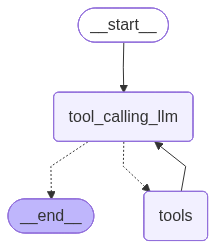

In [ ]:
# -*- coding: utf-8 -*-

import os
import pandas as pd
from datetime import datetime
from typing import Annotated
from typing_extensions import TypedDict

from langchain_community.tools import TavilySearchResults
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages

# Load environment variables
from dotenv import load_dotenv
load_dotenv()

# ------------------------------------------------------------------
# State definition for the agent
# ------------------------------------------------------------------
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function in the
    # annotation defines how this state key should be updated
    messages: Annotated[list, add_messages]


# ------------------------------------------------------------------
# Tool definitions
# ------------------------------------------------------------------
@tool
def multiply(a: int, b: int) -> int:
    """
    Multiplies two numbers.
    """
    return a * b


@tool
def internet_search(query: str):
    """
    Search the web for realtime and latest information (news, weather, etc.).
    """
    search = TavilySearchResults(
        max_results=2,
        search_depth='advanced',
        include_answer=True,
        include_raw_content=True,
    )
    return search.invoke(query)


@tool
def llm_search(query: str):
    """
    Use the LLM model for general and basic information.
    """
    return llm.invoke(query)


@tool
def fetch_portfolio_from_broker():
    """
    Fetch portfolio from broker.
    """
    return smartApi.holding()


@tool
def fetch_data_from_broker(symbol: str, interval: str, start_date: str, end_date: str):
    """
    Retrieve OHLCV candle data from broker and add high/low indicators.
    """
    data = smartApi.getCandleData({
        "exchange": 'NSE',
        "symboltoken": token_fetcher.get_symbol_token(symbol),
        "interval": interval,
        "fromdate": start_date,
        "todate": end_date,
    })['data']
    return add_new_high_low_indicators(data)


@tool
def add_high_low_indicators(data):
    """
    Enrich the OHLCV data with high/low and drawdown indicators.
    """
    return add_new_high_low_indicators(data)


# ------------------------------------------------------------------
# LLM configuration
# ------------------------------------------------------------------
llm = ChatOllama(
    model="gpt-oss:latest",
    validate_model_on_init=True,
    temperature=0
)

# Bind tools to the LLM
tools = [multiply, add_high_low_indicators, fetch_data_from_broker, fetch_portfolio_from_broker]
llm_with_tools = llm.bind_tools(tools)

# ------------------------------------------------------------------
# Graph definition
# ------------------------------------------------------------------
def tool_calling_llm(state: State):
    """
    Node that calls the LLM with the current state messages.
    """
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

# Compile the graph
graph = builder.compile()

# ------------------------------------------------------------------
# Visualize the graph (optional)
# ------------------------------------------------------------------
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # If running outside a notebook, skip visualization
    pass

# ------------------------------------------------------------------
# Example usage (uncomment to test)
# ------------------------------------------------------------------
# response = llm.invoke("What is 4 multiplied by 8?")
# print(response)

In [ ]:
# -*- coding: utf-8 -*-

"""
Agentic trading notebook converted to a clean, executable Python module.
"""

# ------------------------------------------------------------------
# Imports
# ------------------------------------------------------------------
import os
import pandas as pd
from datetime import datetime
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv
from langchain_community.tools import TavilySearchResults
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages

# ------------------------------------------------------------------
# Environment
# ------------------------------------------------------------------
load_dotenv()  # Load variables from .env

# ------------------------------------------------------------------
# Helper: Symbol master & token fetcher
# ------------------------------------------------------------------
def load_symbol_master(file_path: str) -> pd.DataFrame:
    """Load symbol master data from a JSON file."""
    return pd.read_json(file_path).T.reset_index()


class TokenFetcher:
    """Retrieve exToken values for NSE tickers."""

    def __init__(self, symbol_master_df: pd.DataFrame):
        self.symbol_master_df = symbol_master_df

    def get_symbol_token(self, sym_ticker: str):
        """Return the exToken for a given ticker."""
        try:
            return self.symbol_master_df.loc[
                self.symbol_master_df["symTicker"] == sym_ticker, "exToken"
            ].iloc[0]
        except Exception as e:
            print(f"Error fetching symbol token: {e}")
            return None

    def get_symbol_token_list(self, stocks_list):
        """Return a dict of ticker → exToken for a list of tickers."""
        return {stock: self.get_symbol_token(stock) for stock in stocks_list}


# ------------------------------------------------------------------
# Initialise symbol master and token fetcher
# ------------------------------------------------------------------
symbol_master_df = load_symbol_master(
    "/Users/praprsa/Documents/NSE_CM_sym_master.json"
)
token_fetcher = TokenFetcher(symbol_master_df)

# ------------------------------------------------------------------
# State definition
# ------------------------------------------------------------------
class State(TypedDict):
    """
    State used by the LangGraph agent.
    `messages` contains the conversation history.
    """
    messages: Annotated[list, add_messages]


# ------------------------------------------------------------------
# Tool definitions
# ------------------------------------------------------------------
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b


@tool
def internet_search(query: str):
    """Search the web for realtime and latest information."""
    search = TavilySearchResults(
        max_results=2,
        search_depth="advanced",
        include_answer=True,
        include_raw_content=True,
    )
    return search.invoke(query)


@tool
def llm_search(query: str):
    """Use the LLM model for general and basic information."""
    return llm.invoke(query)


@tool
def fetch_portfolio_from_broker():
    """Fetch portfolio from broker."""
    return smartApi.holding()


@tool
def fetch_data_from_broker(symbol: str, interval: str, start_date: str, end_date: str):
    """
    Retrieve OHLCV candle data from broker and add high/low indicators.
    """
    data = smartApi.getCandleData(
        {
            "exchange": "NSE",
            "symboltoken": token_fetcher.get_symbol_token(symbol),
            "interval": interval,
            "fromdate": start_date,
            "todate": end_date,
        }
    )["data"]
    return add_new_high_low_indicators(data)


@tool
def add_high_low_indicators(data):
    """
    Enrich the OHLCV data with high/low and drawdown indicators.
    """
    return add_new_high_low_indicators(data)


# ------------------------------------------------------------------
# LLM configuration
# ------------------------------------------------------------------
llm = ChatOllama(
    model="gpt-oss:latest",
    validate_model_on_init=True,
    temperature=0,
)

# Bind tools to the LLM
tools = [
    multiply,
    add_high_low_indicators,
    fetch_data_from_broker,
    fetch_portfolio_from_broker,
]
llm_with_tools = llm.bind_tools(tools)


# ------------------------------------------------------------------
# Graph definition
# ------------------------------------------------------------------
def tool_calling_llm(state: State):
    """LLM node that processes the current conversation."""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

graph = builder.compile()


# ------------------------------------------------------------------
# Optional: Visualise the graph (only works in notebooks)
# ------------------------------------------------------------------
try:
    from IPython.display import Image, display

    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


# ------------------------------------------------------------------
# Example usage
# ------------------------------------------------------------------
if __name__ == "__main__":
    # Example 1: Portfolio performance query
    response = graph.invoke({"messages": "What is portfolio performance today for my account"})
    for msg in response["messages"]:
        msg.pretty_print()
    # Print the content of the last message
    print(response["messages"][-1].content)

    # Example 2: High/low indicator prompt
    high_low_prompt = "Calculate high/low indicators for TCS stock data from 2024-01-01 to 2024-01-31"
    response = graph.invoke({"messages": high_low_prompt})
    for msg in response["messages"]:
        msg.pretty_print()
    print(response["messages"][-1].content)

    # Example 3: Token fetcher demo
    print(token_fetcher.get_symbol_token("NSE:TCS-EQ"))
    print(token_fetcher.get_symbol_token_list(["NSE:TCS-EQ"]))

In [ ]:
# -*- coding: utf-8 -*-

"""
Broker client utilities.

This module wraps the SmartConnect API and provides convenient
functions for authentication, date formatting and historic
candle data retrieval.  All sensitive information (API key,
user credentials, TOTP secret) should be supplied via environment
variables or a secure secrets manager – never hard‑coded in source.

Example usage
-------------
>>> from broker_client import BrokerClient
>>> client = BrokerClient()          # loads secrets from env
>>> client.login()                   # establishes a session
>>> data = client.fetch_historic(
...     exchange="NSE",
...     symbol_token="ABC123",
...     start="2024-01-01 00:00",
...     end="2024-01-31 23:59",
...     interval="ONE_DAY"
... )
>>> print(data[:5])                  # show first 5 rows
"""

import os
import time
from datetime import datetime
from typing import Any, Dict, List

import pyotp
from logzero import logger
from SmartApi import SmartConnect


class BrokerClient:
    """
    Encapsulates SmartConnect session handling and helper methods.

    Parameters
    ----------
    api_key : str
        SmartConnect API key.  Defaults to the ``SMARTAPI_KEY`` environment
        variable.
    username : str
        Username for the broker account.  Defaults to ``SMARTAPI_USERNAME``.
    password : str
        Password for the broker account.  Defaults to ``SMARTAPI_PASSWORD``.
    totp_secret : str
        TOTP secret used to generate a time‑based OTP.  Defaults to
        ``SMARTAPI_TOTP_SECRET``.
    """

    def __init__(
        self,
        api_key: str | None = None,
        username: str | None = None,
        password: str | None = None,
        totp_secret: str | None = None,
    ) -> None:
        self.api_key = api_key or os.getenv("SMARTAPI_KEY")
        self.username = username or os.getenv("SMARTAPI_USERNAME")
        self.password = password or os.getenv("SMARTAPI_PASSWORD")
        self.totp_secret = totp_secret or os.getenv("SMARTAPI_TOTP_SECRET")

        if not all([self.api_key, self.username, self.password, self.totp_secret]):
            missing = [
                name
                for name, val in {
                    "SMARTAPI_KEY": self.api_key,
                    "SMARTAPI_USERNAME": self.username,
                    "SMARTAPI_PASSWORD": self.password,
                    "SMARTAPI_TOTP_SECRET": self.totp_secret,
                }.items()
                if not val
            ]
            raise ValueError(f"Missing required env vars: {', '.join(missing)}")

        self.smart_api = SmartConnect(self.api_key)

    # ------------------------------------------------------------------
    # Session handling
    # ------------------------------------------------------------------
    def login(self) -> str:
        """
        Authenticates with the broker and establishes a session.

        Returns
        -------
        str
            Confirmation message.
        """
        totp_code = pyotp.TOTP(self.totp_secret).now()
        try:
            self.smart_api.generateSession(self.username, self.password, totp_code)
            logger.info("Login successful.")
            return "Login Successful!"
        except Exception as exc:
            logger.error(f"Login failed: {exc}")
            raise

    # ------------------------------------------------------------------
    # Utility helpers
    # ------------------------------------------------------------------
    @staticmethod
    def _convert_date_to_string(dt: datetime) -> str:
        """
        Convert a :class:`datetime.datetime` to the format expected by
        SmartConnect: ``YYYY-MM-DD HH:MM``.
        """
        return dt.strftime("%Y-%m-%d %H:%M")

    # ------------------------------------------------------------------
    # Data retrieval
    # ------------------------------------------------------------------
    def fetch_historic(
        self,
        exchange: str,
        symbol_token: str,
        start: str,
        end: str,
        interval: str = "ONE_DAY",
    ) -> List[Dict[str, Any]]:
        """
        Retrieve historic candle data for a given symbol.

        Parameters
        ----------
        exchange : str
            Exchange name, e.g. ``"NSE"``.
        symbol_token : str
            Token for the symbol (e.g. ``"ABC123"``).
        start : str
            Start date/time in ``YYYY-MM-DD HH:MM`` format.
        end : str
            End date/time in ``YYYY-MM-DD HH:MM`` format.
        interval : str, optional
            Candle interval – default is ``"ONE_DAY"``.

        Returns
        -------
        list[dict]
            List of candle data dictionaries.
        """
        params = {
            "exchange": exchange,
            "symboltoken": symbol_token,
            "interval": interval,
            "fromdate": start,
            "todate": end,
        }
        try:
            response = self.smart_api.getCandleData(params)
            logger.debug("Historic data retrieved: %s items", len(response["data"]))
            time.sleep(0.2)  # rate‑limit guard
            return response["data"]
        except Exception as exc:
            logger.exception(f"Historic API failed: {exc}")
            raise

    # Convenience wrapper that accepts datetime objects
    def fetch_historic_datetime(
        self,
        exchange: str,
        symbol_token: str,
        start_dt: datetime,
        end_dt: datetime,
        interval: str = "ONE_DAY",
    ) -> List[Dict[str, Any]]:
        """
        Same as :meth:`fetch_historic` but accepts ``datetime`` objects.
        """
        start = self._convert_date_to_string(start_dt)
        end = self._convert_date_to_string(end_dt)
        return self.fetch_historic(exchange, symbol_token, start, end, interval)


# ------------------------------------------------------------------
# Demo
# ------------------------------------------------------------------
if __name__ == "__main__":
    # Ensure environment variables are set before running this demo.
    client = BrokerClient()
    print(client.login())

    # Example: fetch 5 days of daily candles for a symbol
    try:
        data = client.fetch_historic(
            exchange="NSE",
            symbol_token="ABC123",
            start="2024-01-01 00:00",
            end="2024-01-05 23:59",
            interval="ONE_DAY",
        )
        for row in data:
            print(row)
    except Exception as e:
        logger.error(f"Data fetch failed: {e}")

In [ ]:
# -*- coding: utf-8 -*-

"""
Convenience functions for fetching broker data and enriching it
with high/low indicators.
"""

import pandas as pd
from datetime import datetime

# Assume the following helpers are available from earlier modules:
#   - token_fetcher : TokenFetcher instance
#   - fetch_hdata_from : broker data retrieval wrapper
#   - convert_date_to_string : datetime → 'YYYY-MM-DD HH:MM' string


# --------------------------------------------------------------------
# 1. Data fetching helpers
# --------------------------------------------------------------------
def fetch_intraday_data(symbol: str, *, interval: str = "FIVE_MINUTE") -> pd.DataFrame:
    """
    Retrieve the most recent full trading day for ``symbol`` from the broker
    and enrich it with high/low indicators.

    Parameters
    ----------
    symbol : str
        Ticker symbol without exchange prefix (e.g. "OIL").
    interval : str, optional
        Candle interval requested from the broker.

    Returns
    -------
    pd.DataFrame
        DataFrame with OHLCV data plus indicator columns.
    """
    exchange = "NSE"
    start = datetime(2025, 10, 30, 0, 0)
    end = start + pd.DateOffset(days=1)

    raw_data = fetch_hdata_from(
        exchange=exchange,
        symboltoken=token_fetcher.get_symbol_token(f"{exchange}:{symbol}-EQ"),
        start=convert_date_to_string(start),
        end=convert_date_to_string(end),
        interval=interval,
    )
    return add_new_high_low_indicators(raw_data)


# --------------------------------------------------------------------
# 2. High / low indicator enrichment
# --------------------------------------------------------------------
def add_new_high_low_indicators(data: list) -> pd.DataFrame:
    """
    Enrich OHLCV data with new‑high / new‑low indicators and related metrics.

    The input *data* should be a list of 6‑tuples: ``(timestamp, open, high,
    low, close, volume)``.  The function never mutates the input and returns
    a copy of the enriched DataFrame.

    Parameters
    ----------
    data : list[tuple]
        Raw candle data.

    Returns
    -------
    pd.DataFrame
        DataFrame with the following additional columns:

        * ``cumulative_high`` (float)
        * ``cumulative_low`` (float)
        * ``new_high`` (bool)
        * ``new_low`` (bool)
        * ``range`` (float)
        * ``range_percent`` (float)
        * ``high_drawdown`` (float, %)
        * ``low_drawdown`` (float, %)
        * ``OH`` (bool)
        * ``OL`` (bool)
        * ``doji`` (bool)
        * ``pivot`` (float)
    """
    cols = ["timestamp", "open", "high", "low", "close", "volume"]
    df = pd.DataFrame([dict(zip(cols, row)) for row in data])

    # Cumulative high/low
    df["cumulative_high"] = df["high"].cummax()
    df["cumulative_low"] = df["low"].cummin()

    # Flags for new high / low
    df["new_high"] = df["high"] == df["cumulative_high"]
    df["new_low"] = df["low"] == df["cumulative_low"]

    # Range and percent
    df["range"] = df["cumulative_high"] - df["cumulative_low"]
    first_close = df["close"].iloc[0]
    df["range_percent"] = (df["range"] / first_close) * 100 if first_close else pd.NA

    # Drawdowns (as percentages)
    df["high_drawdown"] = 100 * (df["cumulative_high"] - df["close"]).abs() / df["range"]
    df["low_drawdown"] = 100 * (df["cumulative_low"] - df["close"]).abs() / df["range"]

    # Open‑high / open‑low / doji / pivot
    df["OH"] = df["open"] == df["high"]
    df["OL"] = df["open"] == df["low"]
    df["doji"] = (df["open"] - df["close"]).abs() < 0.10
    df["pivot"] = (df["low"] + df["close"] + df["high"]) / 3

    return df.copy()


# --------------------------------------------------------------------
# 3. Example usage
# --------------------------------------------------------------------
if __name__ == "__main__":
    # Example: fetch intraday data for Nifty Oil
    df = fetch_intraday_data("OIL")
    print(df.head())

    # Filter only new highs
    new_highs = df[df["new_high"]]
    print("Number of new highs:", len(new_highs))

## ==============Latest Code Below ----_____>>>>>>>>>.........

## Working Code v0.1


In [ ]:
# ==============================
# Imports
# ==============================
import os
import time
import pandas as pd
from datetime import datetime

import pyotp
from logzero import logger
from SmartApi import SmartConnect

from dotenv import load_dotenv
from langchain_community.tools import TavilySearchResults
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict, Any, Dict, List, Set
import mplfinance as mpf
# ==============================
# Environment
# ==============================
load_dotenv()  # load .env variables



True

HTTP Request: GET http://127.0.0.1:11434/api/tags "HTTP/1.1 200 OK"


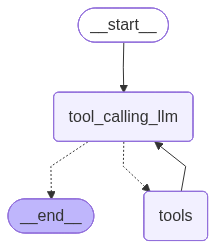

In [ ]:
# -*- coding: utf-8 -*-

"""
Complete, cleaned‑up version of the original notebook.

All components – broker interaction, data enrichment, LLM tooling, and
agent graph – are assembled in a single file for ease of use.
"""
# Global placeholder for the SmartConnect instance – will be set in __main__
smartApi = None
token_fetcher = None
df: pd.DataFrame | None = None

# ==============================
# Helpers
# ==============================
def load_symbol_master(file_path: str) -> pd.DataFrame:
    """Load symbol master data from a JSON file."""
    return pd.read_json(file_path).T.reset_index()


# ==============================
# Token fetcher
# ==============================
class TokenFetcher:
    """Retrieve exToken values for NSE tickers."""

    def __init__(self, symbol_master_df: pd.DataFrame):
        self.symbol_master_df = symbol_master_df

    def get_symbol_token(self, sym_ticker: str) -> str | None:
        """Return the exToken for a given ticker."""
        try:
            logger.info(f"Fetching symbol token for {sym_ticker}")
            return self.symbol_master_df.loc[
                self.symbol_master_df["symTicker"] == sym_ticker, "exToken"
            ].iloc[0]
        except Exception as e:
            logger.error(f"Token fetch failed for {sym_ticker}: {e}")
            return None

    def get_symbol_token_list(self, stocks_list: List[str]) -> Dict[str, str | None]:
        """Return a dict of ticker → exToken for a list of tickers."""
        return {stock: self.get_symbol_token(stock) for stock in stocks_list}


# ==============================
# Broker client
# ==============================
class BrokerClient:
    """
    Wrap SmartConnect and handle authentication / rate limiting.
    """

    def __init__(
        self,
        api_key: str,
        username: str,
        password: str,
        totp_secret: str,
    ):
        self.smart_api = SmartConnect(api_key)
        global smartApi
        smartApi = self.smart_api

        self.username = username
        self.password = password
        self.totp_secret = totp_secret

    def login(self) -> str:
        """Authenticate with the broker."""
        totp_code = pyotp.TOTP(self.totp_secret).now()
        try:
            self.smart_api.generateSession(self.username, self.password, totp_code)
            logger.info("Broker login successful.")
            smartApi = self.smart_api
            return "Login Successful!"
        except Exception as exc:
            logger.error(f"Broker login failed: {exc}")
            raise

    @staticmethod
    def _convert_date_to_string(dt: datetime) -> str:
        """Convert a datetime to the format expected by SmartConnect."""
        return dt.strftime("%Y-%m-%d %H:%M")

    def fetch_historic(
        self,
        exchange: str,
        symbol_token: str,
        start: str,
        end: str,
        interval: str = "ONE_DAY",
    ) -> List[Dict[str, Any]]:
        """Retrieve historic candle data for a symbol."""
        params = {
            "exchange": exchange,
            "symboltoken": symbol_token,
            "interval": interval,
            "fromdate": start,
            "todate": end,
        }
        try:
            response = self.smart_api.getCandleData(params)
            logger.debug("Historic data retrieved: %s items", len(response["data"]))
            time.sleep(0.2)  # guard against rate limits
            return response["data"]
        except Exception as exc:
            logger.exception(f"Historic API failed: {exc}")
            raise

    def fetch_historic_datetime(
        self,
        exchange: str,
        symbol_token: str,
        start_dt: datetime,
        end_dt: datetime,
        interval: str = "ONE_DAY",
    ) -> List[Dict[str, Any]]:
        """Same as fetch_historic but accepts datetime objects."""
        start = self._convert_date_to_string(start_dt)
        end = self._convert_date_to_string(end_dt)
        return self.fetch_historic(exchange, symbol_token, start, end, interval)

def broker_login():
    try:
        broker_client = BrokerClient(
            api_key=os.getenv("SMARTAPI_KEY"),
            username=os.getenv("SMARTAPI_USERNAME"),
            password=os.getenv("SMARTAPI_PASSWORD"),
            totp_secret=os.getenv("SMARTAPI_TOTP_SECRET"),
        )
        logger.info(broker_client.login())
        return broker_client
    except Exception as e:
        logger.error("Failed to initialize or login to BrokerClient: %s", e)

# ==============================
# Data enrichment
# ==============================
def add_new_high_low_indicators(data: List) -> pd.DataFrame:
    """
    Enrich OHLCV data with new‑high / new‑low indicators and related metrics.

    Input is a list of 6‑tuples:
        (timestamp, open, high, low, close, volume)
    """
    cols = ["timestamp", "open", "high", "low", "close", "volume"]
    df = pd.DataFrame([dict(zip(cols, row)) for row in data])

    # Cumulative high/low
    df["cumulative_high"] = df["high"].cummax()
    df["cumulative_low"] = df["low"].cummin()

    # Flags for new high / low
    df["new_high"] = df["high"] == df["cumulative_high"]
    df["new_low"] = df["low"] == df["cumulative_low"]
    # Force the first candle to be *neither* a new high nor a new low
    df.at[0, "new_high"] = False
    df.at[0, "new_low"] = False

    # Range & percent
    df["range"] = df["cumulative_high"] - df["cumulative_low"]
    first_close = df["close"].iloc[0]
    first_open = df["open"].iloc[0]
    df["range_percent"] = (df["range"] / first_close) * 100 if first_close else pd.NA

    # Drawdowns (percent)
    df["high_drawdown"] = 100 * (df["cumulative_high"] - df["close"]).abs() / first_open
    df["low_drawdown"] = 100 * (df["cumulative_low"] - df["close"]).abs() / first_open

    # Open‑high / open‑low / doji / pivot
    df["OH"] = df["open"] == df["high"]
    df["OL"] = df["open"] == df["low"]
    df["doji"] = (df["open"] - df["close"]).abs() < 0.10
    df["pivot"] = (df["low"] + df["high"]) / 2

    return df.copy()

# ==============================
# Broker data retrieval (low‑level)
# ==============================
def convert_date_to_string(dt: datetime) -> str:
    """Return a string in the format expected by SmartConnect."""
    return dt.strftime("%Y-%m-%d %H:%M")


from dateutil import parser

def convert_string_to_date(date_str: str) -> datetime:
    """Parse a SmartConnect date string without an explicit format."""
    return parser.parse(date_str)


def fetch_intraday_data(
    symbol: str,
    start_date: datetime,
    interval: str = "FIVE_MINUTE",
    exchange: str = "NSE",
) -> pd.DataFrame:
    """
    Retrieve the most recent full trading day for *symbol* from the broker
    and enrich it with high/low indicators.
    """
    # start = datetime(2025, 10, 30, 0, 0)
    start=convert_string_to_date(start_date)
    end = start + pd.DateOffset(days=1)

    raw_data = fetch_hdata_from(
        exchange=exchange,
        symboltoken=token_fetcher.get_symbol_token(f"{exchange}:{symbol}-EQ"),
        start=convert_date_to_string(start),
        end=convert_date_to_string(end),
        interval=interval,
    )
    return add_new_high_low_indicators(raw_data)


def fetch_hdata_from(
    exchange: str,
    symboltoken: str,
    start: str,
    end: str,
    interval: str,
) -> List:
    """
    Wrapper around SmartConnect.getCandleData that accepts string dates.
    """
    params = {
        "exchange": exchange,
        "symboltoken": symboltoken,
        "interval": interval,
        "fromdate": start,
        "todate": end,
    }
    try:
        response = broker_client.smart_api.getCandleData(params)
        logger.debug("Fetched %s candles", len(response["data"]))
        time.sleep(0.2)  # rate‑limit guard
        return response["data"]
    except Exception as exc:
        logger.exception(f"fetch_hdata_from failed: {exc}")
        raise



# ------------------------------------------------------------------
# State definition for the agent
# ------------------------------------------------------------------
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function in the
    # annotation defines how this state key should be updated
    messages: Annotated[list, add_messages]


@tool
def search(query: str) -> str:
    """Simple web search using Tavily."""
    client = TavilySearchResults()
    results = client.run(query)
    return results


@tool
def ask_lm(question: str) -> str:
    """Ask the OpenAI‑like LLM and return the answer."""
    return llm.invoke(question)

@tool
def fetch_portfolio_from_broker() -> Any:
    """
    Fetch portfolio from broker.

    This tool simply forwards a request to the broker API's `holding`
    endpoint.  It assumes that the global ``smartApi`` variable has
    already been populated with a ``SmartConnect`` instance (see
    ``__main__`` for where this is done).
    """
    if smartApi is None:
        raise RuntimeError("Broker client not yet initialised.")
    # The SmartApi wrapper exposes a ``holding`` method that returns
    # the current portfolio.
    return smartApi.holding()


@tool
def fetch_data_from_broker(symbol: str, interval: str, start_date: str, end_date: str):
    """
    Retrieve OHLCV candle data from broker and add high/low indicators. 
    "    :param symbol: stock symbol in capital letters,
    "    :param interval: FIVE_MINUTE, ONE_HOUR, ONE_DAY etc\n",
    "    :param start_date: str in '%Y-%m-%d %H:%M' format. start date should be before the end date by 1 day for intraday data.\n",
    "    :param end_date: str in '%Y-%m-%d %H:%M' format\n",
    "    :return: 2D array with timestamp, open, high, low, close, volume\n",
    """
    data = smartApi.getCandleData({
        "exchange": 'NSE',
        "symboltoken": token_fetcher.get_symbol_token(f"NSE:{symbol}-EQ"),
        "interval": interval,
        "fromdate": start_date,
        "todate": end_date,
    })['data']
    return add_new_high_low_indicators(data)


@tool
def add_high_low_indicators(data):
    """
    Enrich the OHLCV data with high/low and drawdown indicators.
    """
    return add_new_high_low_indicators(data)

@tool
def fetch_symbol_token_tool(symbol):
    """
    Retrieve exToken values for NSE tickers. Required to fetch data from broker.
    """
    return token_fetcher.get_symbol_token(symbol)

@tool
def fetch_intraday_data_tool(symbol, start_date):
    """
    Fetch intraday OHLCV enriched with day high and low indicators and readings.
    "   :param symbol: stock symbol in capital letters
    "   :param start_date: str in '%Y-%m-%d %H:%M' format.
    "   :return: 2D array with timestamp, open, high, low, close, volume",

    """
    global df
    df = fetch_intraday_data(symbol, start_date)
    return df

import os
import logging
from typing import Optional
from pydantic import BaseModel, Field

logging.basicConfig(level="INFO", format="%(message)s")
log = logging.getLogger("rich")


# ---------- Input Schemas ----------

class CreateFolderInput(BaseModel):
    path: str = Field(..., description="The path where the folder should be created")


class CreateFileInput(BaseModel):
    path: str = Field(..., description="The path where the file should be created")
    content: Optional[str] = Field("", description="Initial content of the file")


class WriteToFileInput(BaseModel):
    path: str = Field(..., description="The file path to write to")
    content: str = Field(..., description="Content to write to file")


class ReadFileInput(BaseModel):
    path: str = Field(..., description="The file path to read")


class ListFilesInput(BaseModel):
    path: Optional[str] = Field(".", description="Folder to list. Defaults to current directory.")


class DeleteFileInput(BaseModel):
    path: str = Field(..., description="File path to delete")


# ---------- Tools ----------
@tool
def create_folder(input: CreateFolderInput):
    """Create a new folder at the specified path."""
    full_path = os.path.abspath(input.path)
    try:
        os.makedirs(full_path, exist_ok=True)
        log.info(f"Created folder: {full_path}")
        return {"success": True, "message": f"Folder created at {full_path}"}
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def create_file(input: CreateFileInput):
    """Create a new file with optional content."""
    full_path = os.path.abspath(input.path)
    try:
        with open(full_path, "w") as f:
            f.write(input.content or "")
        log.info(f"Created file: {full_path}")
        return {"success": True, "message": f"File created at {full_path}"}
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def write_to_file(input: WriteToFileInput):
    """Write content to an existing file."""
    full_path = os.path.abspath(input.path)
    try:
        with open(full_path, "w") as f:
            f.write(input.content)
        log.info(f"Wrote to file: {full_path}")
        return {"success": True, "message": f"Content written to {full_path}"}
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def read_file(input: ReadFileInput):
    """Read the contents of a file."""
    full_path = os.path.abspath(input.path)
    try:
        with open(full_path, "r") as f:
            content = f.read()
        log.info(f"Read file: {full_path}")
        return {"success": True, "content": content}
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def list_files(input: ListFilesInput):
    """List files in a folder."""
    full_path = os.path.abspath(input.path)
    try:
        files = os.listdir(full_path)
        log.info(f"Listed files in: {full_path}")
        return {"success": True, "files": files}
    except Exception as e:
        return {"success": False, "error": str(e)}


@tool
def delete_file(input: DeleteFileInput):
    """Delete a file."""
    full_path = os.path.abspath(input.path)
    try:
        os.remove(full_path)
        log.info(f"Deleted file: {full_path}")
        return {"success": True, "message": f"File deleted: {full_path}"}
    except Exception as e:
        return {"success": False, "error": str(e)}

# LLM instance
llm = ChatOllama(model="gpt-oss:latest",
    validate_model_on_init=True,
    temperature=0)


# Bind tools to the LLM
tools = [fetch_intraday_data_tool, fetch_data_from_broker, fetch_portfolio_from_broker, create_file, write_to_file, read_file, list_files, delete_file, create_folder]
llm_with_tools = llm.bind_tools(tools)

# ------------------------------------------------------------------
# Graph definition
# ------------------------------------------------------------------
def tool_calling_llm(state: State):
    """
    Node that calls the LLM with the current state messages.
    """
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

# Compile the graph
graph = builder.compile()

# ------------------------------------------------------------------
# Visualize the graph (optional)
# ------------------------------------------------------------------
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # If running outside a notebook, skip visualization
    pass


# ==============================
# Main demo
# ==============================
if __name__ == "__main__":
    # Wire the global SmartConnect instance for the tool
    global token_fetcher

    # ------------------------------------------------------------------
    # 1. Load symbol master and initialise helpers
    # ------------------------------------------------------------------
    symbol_master_path = os.getenv("SYMBOL_MASTER_JSON")
    if not symbol_master_path:
        raise RuntimeError("Set SYMBOL_MASTER_JSON in .env")

    symbol_master_df = load_symbol_master(symbol_master_path)
    
    token_fetcher = TokenFetcher(symbol_master_df)

    # ------------------------------------------------------------------
    # 2. Broker client (authentication)
    # ------------------------------------------------------------------
    # broker_client = broker_login()
    # global smartApi
    # smartApi = broker_client.smart_api  # ensure global variable is set

    # ------------------------------------------------------------------
    # 3. Fetch some broker data
    # ------------------------------------------------------------------
    # end_date = datetime(2025, 10, 31, 0, 0)
    # start_date = end_date - pd.DateOffset(days=1)

    # raw_data = fetch_hdata_from(
    #     exchange="NSE",
    #     symboltoken=token_fetcher.get_symbol_token("NSE:MFSL-EQ"),
    #     start=convert_date_to_string(start_date),
    #     end=convert_date_to_string(end_date),
    #     interval="FIVE_MINUTE",
    # )

    # ------------------------------------------------------------------
    # 4. Enrich the data with indicators
    # ------------------------------------------------------------------
    # df = add_new_high_low_indicators(raw_data)
    # logger.info("Data enriched – %s rows, %s columns", len(df), len(df.columns))

    # ------------------------------------------------------------------
    # 5. Run the agent on a sample query
    # ------------------------------------------------------------------
    # sample_query = "What is the intraday movement for stock MFSL on 31st Oct 2025.? Give initial bias based on enriched data?"
    # print("\n=== Query : ", sample_query)

    # response = graph.invoke({"messages": sample_query})
    # print("\n=== Agent output ===")
    # for msg in response["messages"]:
    #     msg.pretty_print()

    # ------------------------------------------------------------------
    # 6. (Optional) Plot new highs
    # ------------------------------------------------------------------
    # new_highs = df[df["new_high"]]
    # print(f"Number of new highs: {len(new_highs)}")

In [267]:
# fetch_intraday_data('MFSL', '2025-10-31T00:00')
# broker_login()
input = {
    "symbol": 'MFSL',
    "date": '26th Nov 2025',
    "symbols": ['BAJFINANCE', 'SBIN', 'ICICIBANK', 'TCS', 'HDFCBANK' ]
}
intraday_summary = f"What is the intraday summary for symbol {input['symbol']} on {input['date']}?"
intraday_trade = f"Fetch intraday data, analyze and generate trade in json format for symbol {input['symbol']} on {input['date']}. Give clear reasons for trade action. Take trade in first 30 mins and take profit as soon as momentum dies. Exit trade fully if direction starts reversing after 12:30 in second half of the total trading duration. Next, Analyze the trade performance with help of fetched data."
portfolio_ai = f"Fetch my portfolio from the broker."

def call_ai(prompt: str):
    response = graph.invoke({"messages": prompt})
    print("\n=== Agent output ===")
    for msg in response["messages"]:
        msg.pretty_print()

In [44]:
sample_query = "What is the intraday time price opportunity analysis candle by candle for symbol 'MFSL' on 6th Nov 2025? Identify clear trades. Indian markets open at 9:15 and closes at 3:30. There are morning session till 12:30. After that evening session till 3:30."
# call_ai(intraday_trade)

In [120]:
# call_ai(intraday_summary)

In [46]:
# ------------------------------------------------------------------
# New helper: aggregate intraday “new‑high / new‑low” counts *with* stock metadata
# ------------------------------------------------------------------
from typing import List

def aggregate_intraday_new_high_low_with_meta(
    symbols: List[str],
    start_date: datetime,
    interval: str = "FIVE_MINUTE",
) -> pd.DataFrame:
    """
    Fetch enriched intraday OHLCV data for each symbol, then aggregate
    per‑timestamp counts **and** lists of stocks that hit new highs / lows.

    Parameters
    ----------
    symbols : List[str]
        List of stock symbols (e.g. ["MFSL", "TCS"]).
    start_date : datetime
        Datetime to start fetching data from.  Data for the next trading
        day / interval‑aligned block is returned.
    interval : str, optional
        Candle interval accepted by the broker API.  Default is
        `"FIVE_MINUTE"`.

    Returns
    -------
    pd.DataFrame
        Columns:
        * ``timestamp``          – candle timestamp
        * ``new_high_count``     – how many stocks hit a new high
        * ``new_low_count``      – how many stocks hit a new low
        * ``new_high_stocks``    – list of symbols that hit a new high
        * ``new_low_stocks``     – list of symbols that hit a new low
        * ``cumulative_new_high`` – running total of new‑high stocks
        * ``cumulative_new_low``  – running total of new‑low stocks
    """
    # Storage keyed by timestamp
    ts_stats: dict = {}

    for sym in symbols:
        # Get enriched data for the current symbol
        df = fetch_intraday_data(sym, start_date, interval)

        # Ensure booleans are explicit (True/False)
        df["new_high"] = df["new_high"].astype(bool)
        df["new_low"] = df["new_low"].astype(bool)

        for _, row in df.iterrows():
            ts = row["timestamp"]
            if ts not in ts_stats:
                ts_stats[ts] = {
                    "new_high_count": 0,
                    "new_low_count": 0,
                    "new_high_stocks": [],
                    "new_low_stocks": [],
                }

            if row["new_high"]:
                ts_stats[ts]["new_high_count"] += 1
                ts_stats[ts]["new_high_stocks"].append(sym)

            if row["new_low"]:
                ts_stats[ts]["new_low_count"] += 1
                ts_stats[ts]["new_low_stocks"].append(sym)

    # Build a DataFrame from the aggregated stats
    agg_rows = []
    for ts, stats in ts_stats.items():
        agg_rows.append(
            {
                "timestamp": ts,
                "new_high_count": stats["new_high_count"],
                "new_low_count": stats["new_low_count"],
                "new_high_stocks": stats["new_high_stocks"],
                "new_low_stocks": stats["new_low_stocks"],
            }
        )

    agg_df = pd.DataFrame(agg_rows).sort_values("timestamp").reset_index(drop=True)

    # Running (cumulative) counts
    agg_df["cumulative_new_high"] = agg_df["new_high_count"].cumsum()
    agg_df["cumulative_new_low"] = agg_df["new_low_count"].cumsum()

    return agg_df

In [97]:
# --------------------------------------------------------------------------
# Aggregated intraday high/low counts + per‑symbol close price + signals
# --------------------------------------------------------------------------
from typing import List, Set

def aggregate_intraday_new_high_low_with_meta_and_signals(
    symbols: List[str],
    start_date: datetime,
    interval: str = "FIVE_MINUTE",
) -> pd.DataFrame:
    """
    Fetch enriched intraday OHLCV data for each symbol, then aggregate

    * per‑timestamp counts of new highs / lows,
    * list of symbols that hit a new high / low,
    * a dictionary of close prices per symbol,
    * and a trade signal (buy / sell / wait) that fires on the
      first candle that satisfies the close‑>pivot or close‑<pivot
      rule *at or after* the first new‑high / new‑low respectively.

    Parameters
    ----------
    symbols : List[str]
        List of stock symbols (e.g. ["MFSL", "TCS"]).
    start_date : datetime
        Datetime to start fetching data from.
    interval : str, optional
        Candle interval accepted by the broker API.  Default is
        `"FIVE_MINUTE"`.

    Returns
    -------
    pd.DataFrame
        Columns:
            * timestamp
            * new_high_count
            * new_low_count
            * new_high_stocks
            * new_low_stocks
            * cumulative_new_high
            * cumulative_new_low
            * close_prices          – dict symbol→close
            * signal                – 'buy' / 'sell' / 'wait'
            * signal_stocks         – list of symbols that produced the signal
    """
    # Store the raw enriched data for each symbol
    symbol_df: dict[str, pd.DataFrame] = {}
    first_new_high_ts: dict[str, datetime | None] = {}
    first_new_low_ts: dict[str, datetime | None] = {}
    signaled: dict[str, bool] = {sym: False for sym in symbols}

    for sym in symbols:
        df = fetch_intraday_data(sym, start_date, interval)
        df["new_high"] = df["new_high"].astype(bool)
        df["new_low"] = df["new_low"].astype(bool)

        symbol_df[sym] = df

        # When did the very first new‑high / new‑low happen?
        if not df.loc[df["new_high"]].empty:
            first_new_high_ts[sym] = df.loc[df["new_high"], "timestamp"].iloc[0]
        else:
            first_new_high_ts[sym] = None

        if not df.loc[df["new_low"]].empty:
            first_new_low_ts[sym] = df.loc[df["new_low"], "timestamp"].iloc[0]
        else:
            first_new_low_ts[sym] = None

    # All timestamps that appear in any symbol
    all_timestamps = sorted({ts for df in symbol_df.values() for ts in df["timestamp"]})

    rows = []

    for ts in all_timestamps:
        # Aggregated counts & symbol lists
        new_high_count = 0
        new_low_count = 0
        new_high_stocks = set()
        new_low_stocks = set()

        close_prices = {}

        # Signal logic per symbol
        buy_symbols = []
        sell_symbols = []

        for sym, df in symbol_df.items():
            row = df[df["timestamp"] == ts]
            if row.empty:
                continue  # symbol does not have data for this candle

            row = row.iloc[0]
            close_prices[sym] = row["close"]
            pivot = row["pivot"]

            # Update counts
            if row["new_high"]:
                new_high_count += 1
                new_high_stocks.add(sym)  # add to set
            if row["new_low"]:
                new_low_count += 1
                new_low_stocks.add(sym)   # add to set

            # If this symbol already produced a signal, skip it
            # if signaled[sym]:
            #     continue

            # --- BUY? ---  (after first new‑high, close > pivot)
            # First new‑high itself cannot trigger a buy; we wait until *after* it.
            if (row["new_high"]
                and close_prices[sym] > pivot
                and first_new_high_ts[sym] is not None
                and ts > first_new_high_ts[sym]
                ):
                    buy_symbols.append(sym)
                    signaled[sym] = True

            # --- SELL? ---  (after first new‑low, close < pivot)
            if (row["new_low"]
                and close_prices[sym] < pivot
                and first_new_low_ts[sym] is not None
                and ts >= first_new_low_ts[sym]
            ):
                sell_symbols.append(sym)
                signaled[sym] = True

        # Determine the signal for this timestamp
        if buy_symbols:
            signal = "buy"
            signal_stocks = buy_symbols
        elif sell_symbols:
            signal = "sell"
            signal_stocks = sell_symbols
        else:
            signal = "wait"
            signal_stocks = []

        rows.append(
            {
                "timestamp": ts,
                "new_high_count": new_high_count,
                "new_low_count": new_low_count,
                "new_high_stocks": new_high_stocks,
                "new_low_stocks": new_low_stocks,
                "cumulative_new_high": None,   # will be filled later
                "cumulative_new_low":  None,   # will be filled later
                "close_prices": close_prices,
                "signal": signal,
                "signal_stocks": signal_stocks,
            }
        )

    # Build the DataFrame
    agg_df = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)

    # Running cumulative counts
    agg_df["cumulative_new_high"] = agg_df["new_high_count"].cumsum()
    agg_df["cumulative_new_low"] = agg_df["new_low_count"].cumsum()

    return agg_df, symbol_df

In [112]:
symbols = ["MFSL", "TCS", "HDFCBANK", "RELIANCE"]
start = datetime(2025, 10, 30, 9, 15)   # 1st candle of the day

# summary = aggregate_intraday_new_high_low_with_meta_and_signals(symbols, convert_date_to_string(start))
# summary

In [318]:
# broker_client = broker_login()
# global smartApi
# smartApi = broker_client.smart_api  # ensure global variable is set
symbols = [
    "DIXON",
    "RAYMONDLSL",          # Raymond Lifestyle
    "TATAINVEST",
    "NATCOPHARM",
    "MANAPPURAM",
    "GRAVITA",
    "SIEMENS",
    "NUVAMA",           # Nuvama Wealth
    "PGEL"              # PG Electroplast
]
mf, sdf = aggregate_intraday_new_high_low_with_meta_and_signals(symbols, input['date'])
mf.info()

[I 251126 15:23:23 4070074334:34] Fetching symbol token for NSE:DIXON-EQ
[D 251126 15:23:24 4070074334:238] Fetched 74 candles
[I 251126 15:23:24 4070074334:34] Fetching symbol token for NSE:RAYMONDLSL-EQ
[D 251126 15:23:24 4070074334:238] Fetched 74 candles
[I 251126 15:23:24 4070074334:34] Fetching symbol token for NSE:TATAINVEST-EQ
[D 251126 15:23:25 4070074334:238] Fetched 74 candles
[I 251126 15:23:25 4070074334:34] Fetching symbol token for NSE:NATCOPHARM-EQ
[D 251126 15:23:25 4070074334:238] Fetched 74 candles
[I 251126 15:23:25 4070074334:34] Fetching symbol token for NSE:MANAPPURAM-EQ
[D 251126 15:23:26 4070074334:238] Fetched 74 candles
[I 251126 15:23:26 4070074334:34] Fetching symbol token for NSE:GRAVITA-EQ
[D 251126 15:23:26 4070074334:238] Fetched 74 candles
[I 251126 15:23:26 4070074334:34] Fetching symbol token for NSE:SIEMENS-EQ
[D 251126 15:23:27 4070074334:238] Fetched 74 candles
[I 251126 15:23:27 4070074334:34] Fetching symbol token for NSE:NUVAMA-EQ
[D 251126 15:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   timestamp            74 non-null     object
 1   new_high_count       74 non-null     int64 
 2   new_low_count        74 non-null     int64 
 3   new_high_stocks      74 non-null     object
 4   new_low_stocks       74 non-null     object
 5   cumulative_new_high  74 non-null     int64 
 6   cumulative_new_low   74 non-null     int64 
 7   close_prices         74 non-null     object
 8   signal               74 non-null     object
 9   signal_stocks        74 non-null     object
dtypes: int64(4), object(6)
memory usage: 5.9+ KB


In [ ]:
# --- Imports ---------------------------------------------------------
import pandas as pd
import mplfinance as mpf   # pip install mplfinance (if you don’t have it)

# ------------------------------------------------------------------
# 1.  Helper: clean a single symbol’s DataFrame
# ------------------------------------------------------------------
def _clean_symbol_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Mutate the given DataFrame so that:
        • `timestamp` is a DatetimeIndex
        • only the columns ['open', 'high', 'low', 'close', 'volume'] remain
    """
    df = df.copy()                               # avoid mutating the caller’s DF
    df["timestamp"] = pd.to_datetime(df["timestamp"])  # string → datetime
    df.set_index("timestamp", inplace=True)      # mplfinance likes a DatetimeIndex
    # Keep only the OHLCV columns – mplfinance will ignore anything else
    return df[["open", "high", "low", "close", "volume"]]


# ------------------------------------------------------------------
# 2.  The public transformer
# ------------------------------------------------------------------
def transform_sdf_for_plotting(sdf: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    """
    Accepts the dict `sdf` (symbol → raw DataFrame) and returns a new dict where
    each DataFrame has been cleaned for `mplfinance`.

    Parameters
    ----------
    sdf : dict[str, pd.DataFrame]
        Raw data from the broker.  Each value may have arbitrary columns.

    Returns
    -------
    dict[str, pd.DataFrame]
        One‑to‑one mapping where every DataFrame is ready to feed into
        `mplfinance.plot()`.
    """
    cleaned = {}
    for sym, df in sdf.items():
        cleaned[sym] = _clean_symbol_df(df)
    return cleaned

# Assume `sdf` already exists – a dict of symbol → raw DataFrame
cleaned_sdf = transform_sdf_for_plotting(sdf)

# Example: plot a single symbol
mpf.plot(
    cleaned_sdf["BAJFINANCE"],
    type="candle",
    volume=True,
    style="yahoo",
    title="BAJFINANCE 5‑Minute Candles",
    ylabel="Price",
    ylabel_lower="Volume",
    tight_layout=True,
)
print(sdf.keys())
# If you want to plot **multiple symbols at once** you can iterate:
# for sym, df in cleaned_sdf.items():
#     mpf.plot(df, type="candle", volume=True, title=f"{sym} – 5‑Minute")

In [280]:
# cleaned_sdf['SBIN']

In [151]:
import numpy as np

# ------------------------------------------------------------------
# 2.  Helper – plot a single symbol with the “new_high” / “new_low” flags
# ------------------------------------------------------------------
def plot_symbol_with_signals(df: pd.DataFrame, symbol: str,
                             title: str | None = None,
                             add_volume: bool = True,
                             style: str = "classic",
                             figscale: float = 1.2) -> None:
    """
    Render a candlestick chart **plus** two scatter layers:

        • ▲  at the high of every candle flagged as a new high
        • ▼  at the low of every candle flagged as a new low

    The scatter layers are built as *Series* that share the same index as the
    main DataFrame.  If a symbol has **no** new‑high or new‑low flags, the
    corresponding scatter layer is simply omitted – this prevents the
    “zero‑size array to reduction operation maximum” error you were seeing.
    """
    # ---- 1️⃣  Ensure DatetimeIndex -----------------------------------------
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df.set_index("timestamp", inplace=True)

    # ---- 2️⃣  Create marker series that align with the full index ----------
    # Use float‑type NaNs so matplotlib automatically skips them.
    high_marker = pd.Series(np.nan, index=df.index, dtype=float)
    low_marker  = pd.Series(np.nan, index=df.index, dtype=float)

    # Fill the marker series where the flags are True.
    high_marker[df["new_high"]] = df.loc[df["new_high"], "high"].astype(float)
    low_marker[df["new_low"]]   = df.loc[df["new_low"], "low"].astype(float)

    # ---- 3️⃣  Build the scatter layers only if there are markers ------------
    addplot = []

    if high_marker.notna().any():
        ap_high = mpf.make_addplot(
            high_marker,
            type="scatter",
            markersize=200,
            marker="^",
            color="g",
            panel=0,                     # same pane as the candles
        )
        addplot.append(ap_high)

    if low_marker.notna().any():
        ap_low = mpf.make_addplot(
            low_marker,
            type="scatter",
            markersize=200,
            marker="v",
            color="r",
            panel=0,
        )
        addplot.append(ap_low)
    
    # ---- 4️⃣  Add VWAP plot -----------------------------------------------
    vwap = (df["close"] * df["volume"]).cumsum() / df["volume"].cumsum()
    ap_vwap = mpf.make_addplot(
        vwap,
        type="line",
        color="b",
        panel=0,          # same pane as candles
        width=1.5,
        ylabel="VWAP"
    )
    addplot.append(ap_vwap)

    # ---- 4️⃣  Render the figure ---------------------------------------------
    # ``mplfinance`` does not understand ``plot_nonfinite`` – we simply
    # let the NaNs be ignored.  The style string “default” is not valid,
    # so map it to a real style.
    # if style.lower() == "default":
    #     style = "yahoo"

    mpf.plot(
        df,
        type="candle",
        addplot=addplot,
        volume=add_volume,
        style=style,
        title=title or f"{symbol} – 5‑Minute",
        ylabel="Price",
        ylabel_lower="Volume" if add_volume else None,
        tight_layout=True,
        figscale=figscale,
    )
# ------------------------------------------------------------------
# 3.  Convenience wrapper to plot *all* symbols in your dictionary
# ------------------------------------------------------------------
def plot_all_symbols_with_signals(sdf: dict[str, pd.DataFrame],
                                  add_volume: bool = True) -> None:
    """
    Iterate over the dictionary `sdf` and call `plot_symbol_with_signals` for
    each symbol.  Each symbol will be plotted in a separate figure window.
    """
    for sym, df in sdf.items():
        plot_symbol_with_signals(df, symbol=sym, add_volume=add_volume)

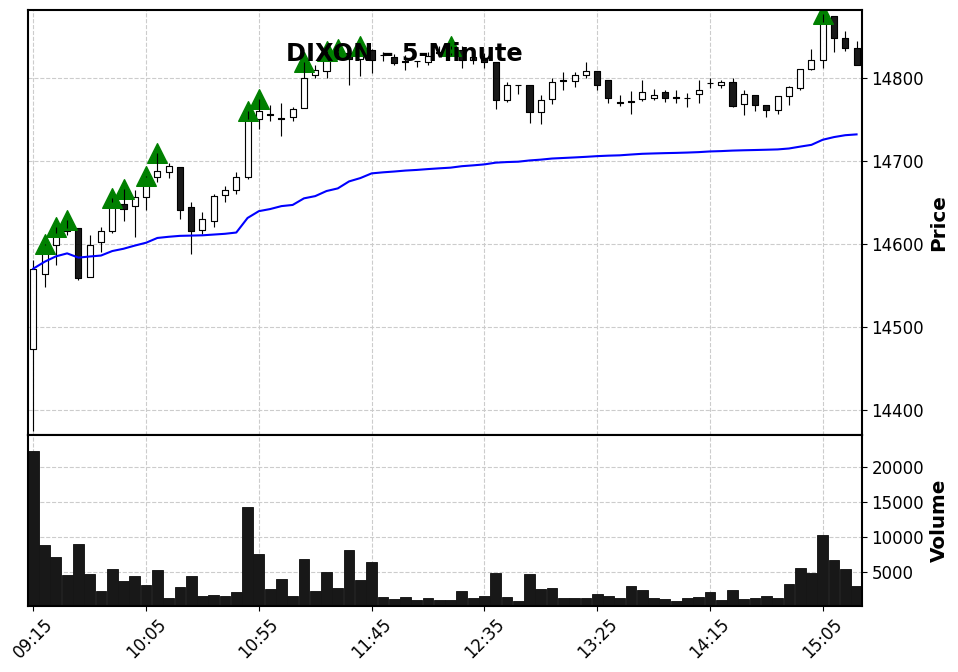

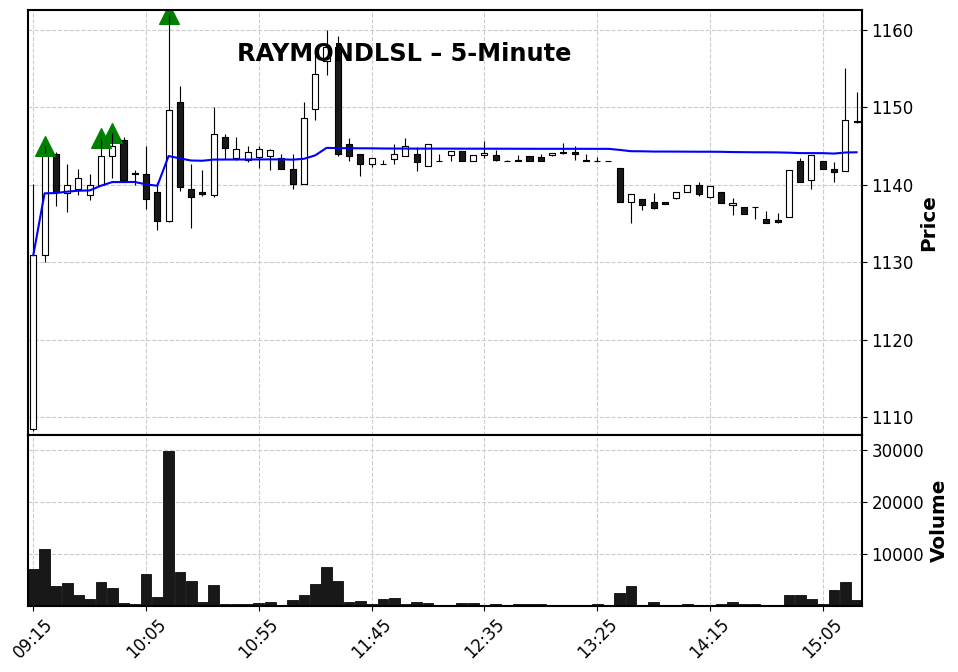

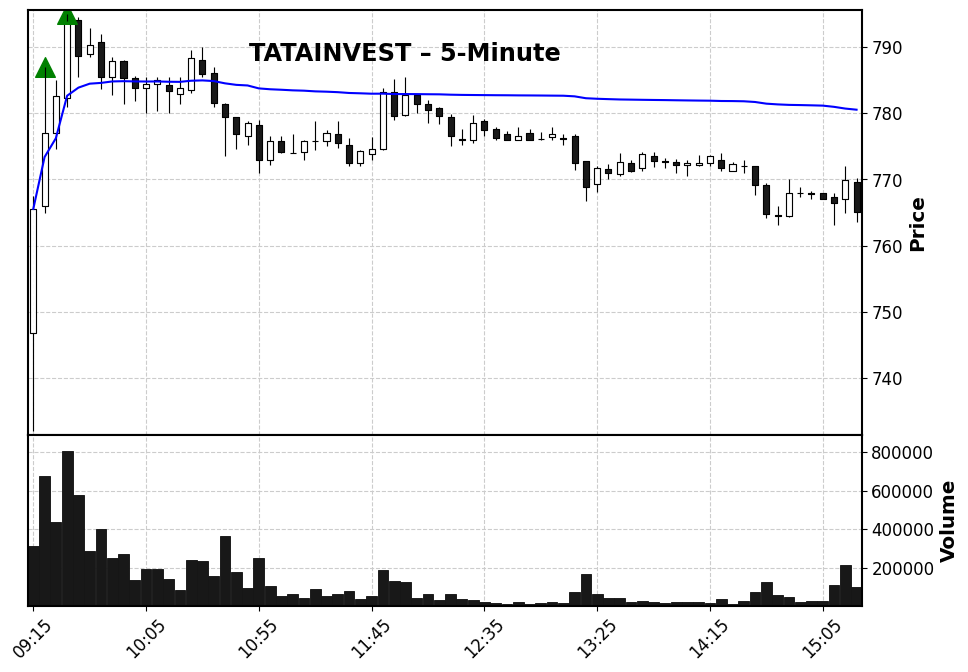

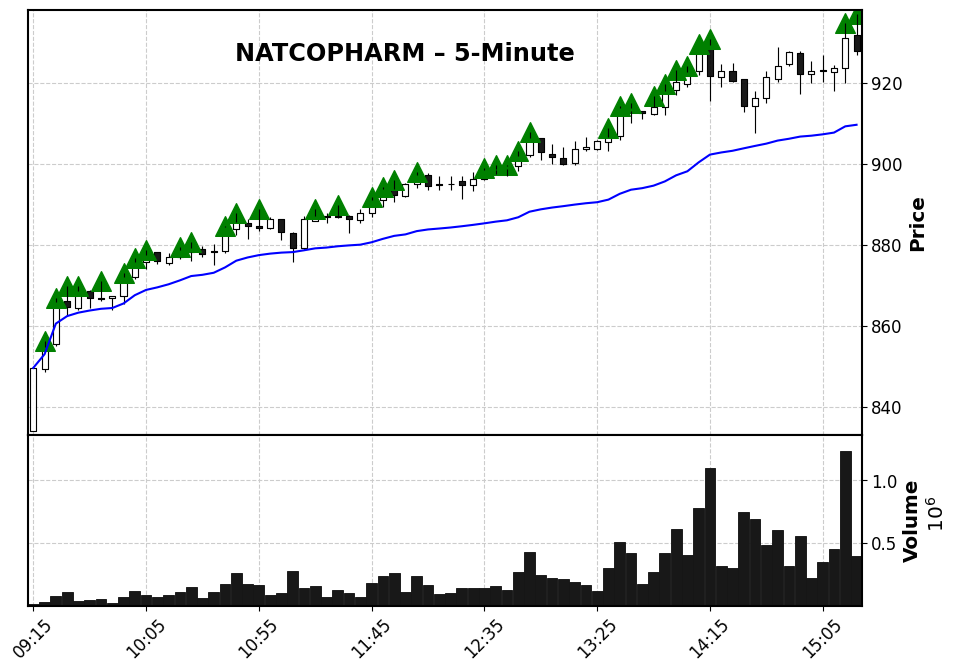

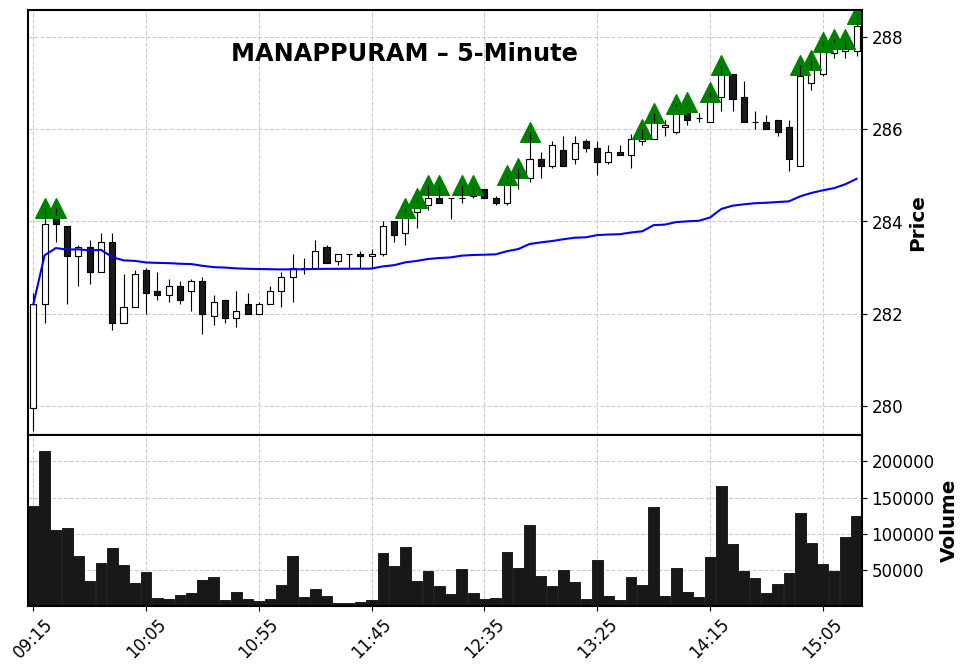

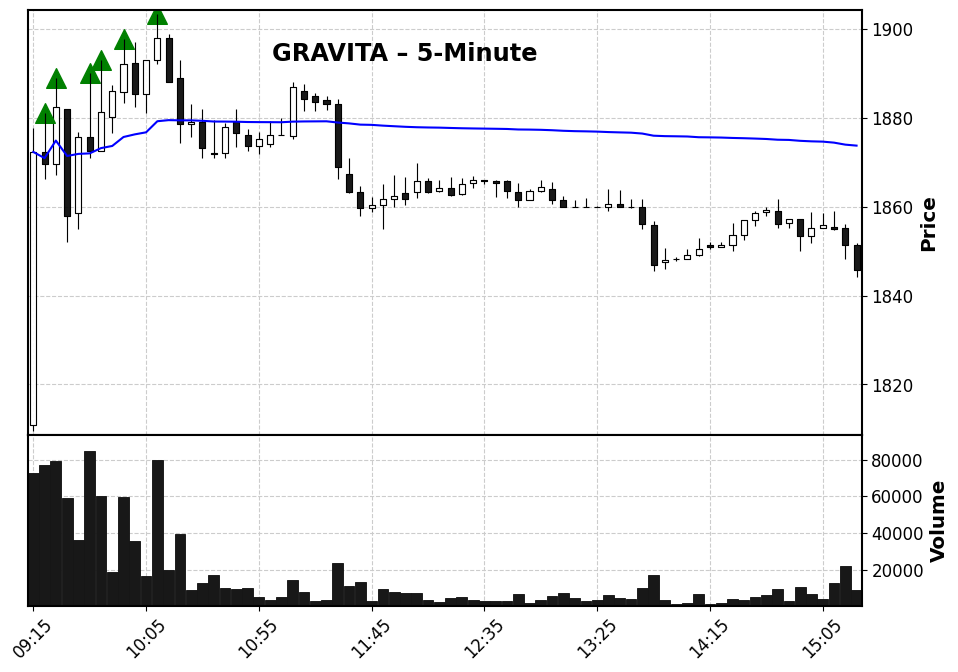

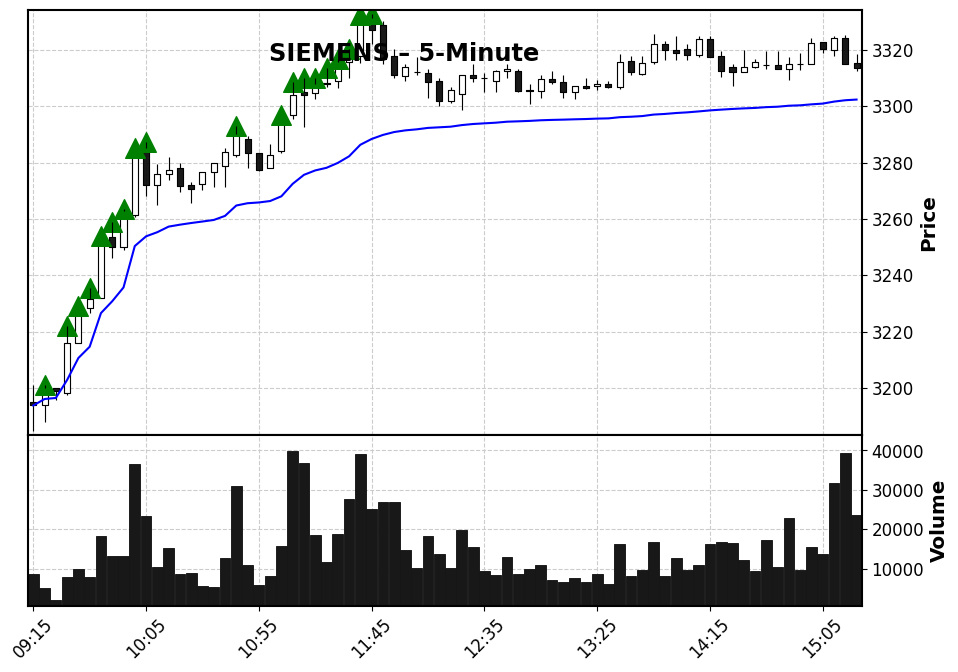

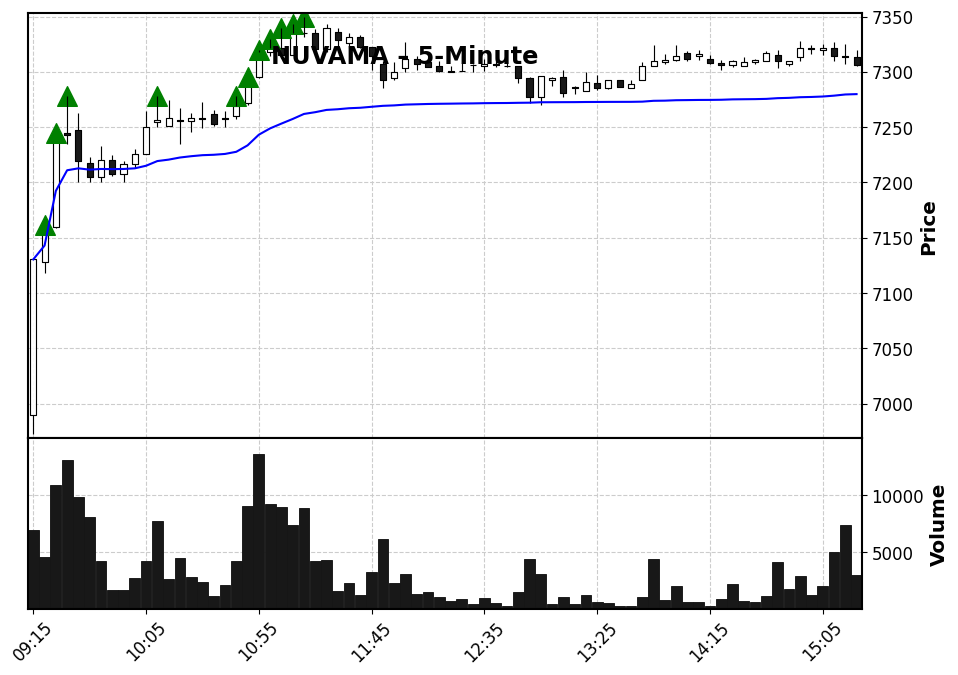

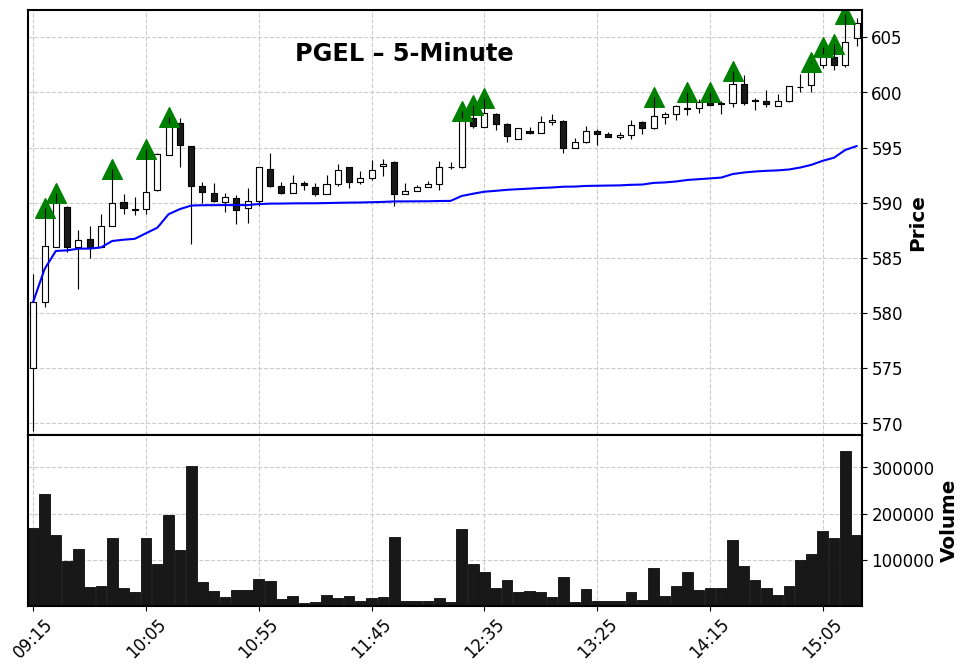

In [319]:
# plot_symbol_with_signals(sdf["BAJFINANCE"], symbol="BAJFINANCE")
plot_all_symbols_with_signals(sdf)



In [84]:
# import mplfinance as mpf
# for st in mpf.available_styles():
#     print(f"Style: {st}")
#     mpf.plot(df, type='candle', style=st, title=f"Style – {st}", volume=True)

In [ ]:
# ────────────────────────────────────────────────────────────────────── #
#  helpers_normalized.py
# ────────────────────────────────────────────────────────────────────── #

import pprint
from typing import List, Dict, Any

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------- #
# 1️⃣  Pretty‑print the entire DataFrame
# --------------------------------------------------------------------------- #
def show_all_rows(df: pd.DataFrame, max_rows: int = 10, max_cols: int = 12) -> None:
    """
    Display **all** rows/columns of a DataFrame in a readable form.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to show.
    max_rows : int, optional
        Max number of rows that will be displayed (default 10).
    max_cols : int, optional
        Max number of columns that will be displayed (default 12).
    """
    with pd.option_context(
        "display.max_rows", max_rows,
        "display.max_columns", max_cols,
    ):
        print(df.to_string(index=False))

# --------------------------------------------------------------------------- #
# 2️⃣  Plot *normalized* close prices for every symbol
# --------------------------------------------------------------------------- #
def plot_normalized_close_prices(mf: pd.DataFrame) -> None:
    """
    Quick helper that simply shows the *normalized* close price curves
    (without any signal markers).  Useful if you only want the lines.

    The function expects the column `close_prices` to contain a *list of
    floats*, one list per symbol.
    """
    # Build a 2‑D DataFrame: each column = a symbol, each row = a timestamp
    close_prices_df = pd.DataFrame(
        mf["close_prices"].tolist(),
        index=pd.to_datetime(mf["timestamp"]),
    )
    # Normalise so that the first value of each column equals 1
    normalized_df = close_prices_df / close_prices_df.iloc[0]

    plt.figure(figsize=(12, 6))
    for col in normalized_df.columns:
        plt.plot(normalized_df.index, normalized_df[col], label=col)

    plt.xlabel("Timestamp")
    plt.ylabel("Normalized Close Price")
    plt.title("Normalized Close Prices Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()

# --------------------------------------------------------------------------- #
# 3️⃣  Print every “action” signal (anything other than ‘wait’)
# --------------------------------------------------------------------------- #
def stock_signals(mf: pd.DataFrame) -> None:
    """
    Iterate over `mf` and print rows that contain an actionable signal
    (i.e. `signal != 'wait'`).

    Parameters
    ----------
    mf : pd.DataFrame
        The multi‑feature DataFrame that must contain the columns
        `timestamp`, `signal`, `signal_stocks`, `close_prices`.
    """
    for _, row in mf.iterrows():
        if row["signal"] != "wait":
            print(
                f"Timestamp: {row['timestamp']}, "
                f"Signal: {row['signal']}, "
                f"Stocks: {row['signal_stocks']}, "
                f"Close Prices: {row['close_prices']}"
            )

# --------------------------------------------------------------------------- #
# 4️⃣  Pretty‑print only the rows that contain new‑high / new‑low symbols
# --------------------------------------------------------------------------- #
def pp(mf: pd.DataFrame) -> None:
    """
    Filter `mf` to keep only rows where at least one symbol is listed in
    `new_high_stocks` **or** `new_low_stocks`.  The result is printed
    in a human‑readable format via `pprint.pprint`.

    Parameters
    ----------
    mf : pd.DataFrame
        Must contain the columns `timestamp`,
        `new_high_stocks`, and `new_low_stocks` (each a list of strings).
    """
    filtered_mf = mf[
        (mf["new_high_stocks"].apply(len) + mf["new_low_stocks"].apply(len)) > 0
    ]
    records = filtered_mf[["timestamp", "new_high_stocks", "new_low_stocks"]].to_dict(
        orient="records"
    )
    pprint.pprint(records)

# --------------------------------------------------------------------------- #
# 5️⃣  NEW:  Plot the *normalized* close prices **plus** high/low markers
# --------------------------------------------------------------------------- #
def plot_normalized_close_prices_with_signals(mf: pd.DataFrame) -> None:
    """
    Plot the normalized close‑price curves and overlay a green ▲ marker for
    every *new high* and a red ▼ marker for every *new low*.

    The function expects the following columns in `mf`:

    * `timestamp`          – :class:`datetime.datetime` or string parseable to it
    * `close_prices`       – :class:`dict[str:float]`   (one list per symbol)
    * `new_high_stocks`    – :class:`list[str]`   (symbols with a new high)
    * `new_low_stocks`     – :class:`list[str]`   (symbols with a new low)

    Notes
    -----
    * The normalization is done relative to the first row of each column.
    * Markers are plotted **at the exact timestamp** where the signal appears,
      using the current y‑value from the *normalized* curve.
    """
    # Build the raw DataFrame from the list‑of‑lists column
    close_prices_df = pd.DataFrame(
        mf["close_prices"].tolist(),
        index=pd.to_datetime(mf["timestamp"]),
    )
    # Normalise every column so that the first value equals 1
    normalized_df = close_prices_df / close_prices_df.iloc[0]

    # ---- Plot the curves ----------------------------------------------- #
    plt.figure(figsize=(12, 6))
    for col in normalized_df.columns:
        plt.plot(normalized_df.index, normalized_df[col], label=col)

    # ---- Overlay high/low markers ----------------------
    for row_idx, row in mf.iterrows():
        ts = pd.to_datetime(row["timestamp"])   # <-- timestamp to use for lookup

        # New‑high symbols – ▲, green
        for symbol in row.get("new_high_stocks", []):
            if symbol in normalized_df.columns:
                # Use the timestamp (not the integer index) to fetch the value
                y = normalized_df.at[ts, symbol]
                plt.scatter(ts, y, color="g", marker="o", s=100, zorder=5)

        # New‑low symbols – ▼, red
        for symbol in row.get("new_low_stocks", []):
            if symbol in normalized_df.columns:
                y = normalized_df.at[ts, symbol]
                plt.scatter(ts, y, color="r", marker="o", s=100, zorder=5)

    plt.xlabel("Timestamp")
    plt.ylabel("Normalized Close Price")
    plt.title("Normalized Close Prices Over Time (with High/Low Signals)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

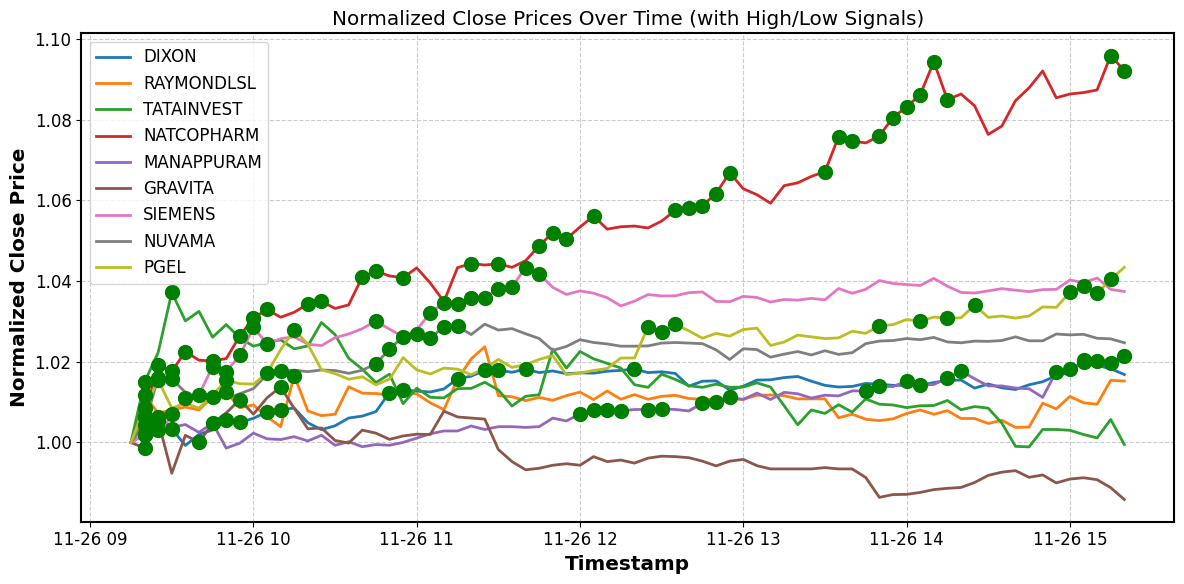

In [320]:
# `mf` is your DataFrame that contains the columns:
#   * timestamp          (datetime)
#   * close_prices       (list[float] – one list per symbol)
#   * new_high_stocks    (list[str]   – symbols with a new high at that row)
#   * new_low_stocks     (list[str]   – symbols with a new low at that row)
#   * signal             (str)       – e.g. 'wait', 'buy', etc.
#   * signal_stocks      (list[str])
#   * close_prices       (list[float])  # same length as `signal_stocks`
#
# 1️⃣  Pretty‑print the whole table
# show_all_rows(mf)

# # 2️⃣  Show all signals that are not “wait”
# stock_signals(mf)

# # 3️⃣  Pretty‑print only the rows that contain new‑high / new‑low symbols
# pp(mf)

# 4️⃣  Plot the normalized close prices with the high/low markers
plot_normalized_close_prices_with_signals(mf)

In [81]:
import pprint
import matplotlib.pyplot as plt

# Show all rows of df in pretty format
def show_all_rows(df: pd.DataFrame):
        pd.option_context('display.max_rows', 10)
        pd.set_option('display.max_columns', 12)

# pd.option_context('display.max_rows', None)
# pd.set_option('display.max_columns', None)

# Plot normalized close_prices for all symbols over time
def plot_normalized_close_prices(mf: pd.DataFrame):
    close_prices_df = pd.DataFrame(mf['close_prices'].tolist(), index=mf['timestamp'])
    normalized_df = close_prices_df / close_prices_df.iloc[0]

    plt.figure(figsize=(12, 6))
    for col in normalized_df.columns:
        plt.plot(normalized_df.index, normalized_df[col], label=col)
    plt.xlabel('Timestamp')
    plt.ylabel('Normalized Close Price')
    plt.title('Normalized Close Prices Over Time')
    plt.legend()
    plt.grid()
    plt.show()

def stock_signals(mf: pd.DataFrame):
    for index, row in mf.iterrows():
        if row['signal'] != 'wait':
            print(f"Timestamp: {row['timestamp']}, Signal: {row['signal']}, Stocks: {row['signal_stocks']}, Close Prices: {row['close_prices']}")

def pp(mf: pd.DataFrame):
    # Filter rows where the total number of elements in both lists is > 0
    filtered_mf = mf[
        (mf['new_high_stocks'].apply(len) + mf['new_low_stocks'].apply(len)) > 0
    ]

    # Convert the filtered rows to a list of dictionaries
    records = filtered_mf[['timestamp', 'new_high_stocks', 'new_low_stocks']].to_dict(orient='records')

    return pprint.pprint(
        records
    )



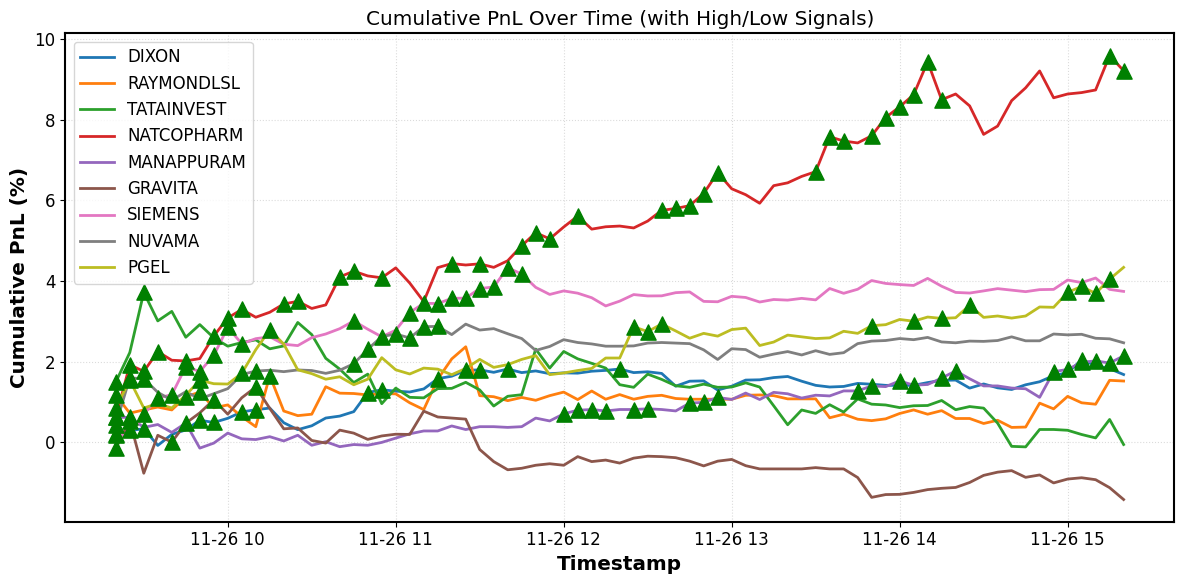

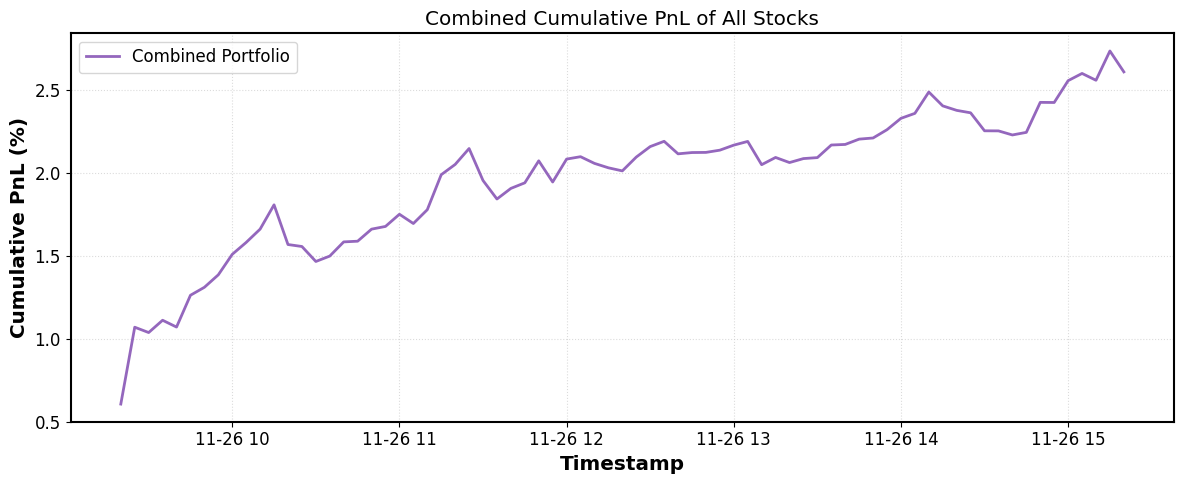

In [321]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_pnl_with_signals(mf: pd.DataFrame) -> None:
    """
    Plot the *cumulative %‑PnL* curves for every symbol and overlay a green ▲
    marker for every new‑high signal and a red ▼ marker for every new‑low
    signal.  The function expects the same columns as
    ``plot_normalized_close_prices_with_signals``:

    * ``timestamp``          – datetime or parseable string
    * ``close_prices``       – list[float] (one list per symbol)
    * ``new_high_stocks``    – list[str]
    * ``new_low_stocks``     – list[str]

    The PnL is computed as:

        1. daily return  =  (P_t – P_{t‑1}) / P_{t‑1}
        2. cumulative PnL =  ∏(1 + return) – 1
    """
    # ------------------------------------------------------------------
    # 1️⃣  Build the raw DataFrame from the list‑of‑lists column
    # ------------------------------------------------------------------
    close_prices_df = pd.DataFrame(
        mf["close_prices"].tolist(),
        index=pd.to_datetime(mf["timestamp"]),
    )

    # ------------------------------------------------------------------
    # 2️⃣  Compute daily returns and cumulative PnL (in %) for each symbol
    # ------------------------------------------------------------------
    returns = close_prices_df.pct_change()          # daily %‑change
    cum_pnl = (1 + returns).cumprod() - 1          # cumulative %‑PnL

    # ------------------------------------------------------------------
    # 3️⃣  Plot the PnL curves
    # ------------------------------------------------------------------
    plt.figure(figsize=(12, 6))
    for col in cum_pnl.columns:
        plt.plot(cum_pnl.index, cum_pnl[col] * 100, label=col)   # *100 → % scale

    # ------------------------------------------------------------------
    # 4️⃣  Overlay high/low markers
    # ------------------------------------------------------------------
    for row_idx, row in mf.iterrows():
        ts = pd.to_datetime(row["timestamp"])

        # New‑high symbols – ▲, green
        for symbol in row.get("new_high_stocks", []):
            if symbol in cum_pnl.columns:
                y = cum_pnl.at[ts, symbol] * 100   # % scale
                plt.scatter(ts, y, color="g", marker="^", s=120, zorder=5)

        # New‑low symbols – ▼, red
        for symbol in row.get("new_low_stocks", []):
            if symbol in cum_pnl.columns:
                y = cum_pnl.at[ts, symbol] * 100
                plt.scatter(ts, y, color="r", marker="v", s=120, zorder=5)

    # ------------------------------------------------------------------
    # 5️⃣  Finalise the figure
    # ------------------------------------------------------------------
    plt.xlabel("Timestamp")
    plt.ylabel("Cumulative PnL (%)")
    plt.title("Cumulative PnL Over Time (with High/Low Signals)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_combined_pnl(mf: pd.DataFrame) -> None:
    """
    Plot a single line that represents the cumulative %‑PnL of the entire
    universe of stocks in ``mf``.  The PnL is calculated by:

    1. Computing the daily percentage change of each symbol’s close price.
    2. Taking the *average* return across all symbols at each time step
       (this is an equal‑weight portfolio).
    3. Building the cumulative product of (1 + average return) and subtracting 1.

    Parameters
    ----------
    mf : pd.DataFrame
        Must contain the columns used by the previous helper:
            * ``timestamp``          – datetime or parseable string
            * ``close_prices``       – list[float] (one list per symbol)
            * ``new_high_stocks``    – list[str] (optional)
            * ``new_low_stocks``     – list[str] (optional)
    """
    # --- 1️⃣  Build the raw close‑price DataFrame -----------------------------
    close_prices_df = pd.DataFrame(
        mf["close_prices"].tolist(),
        index=pd.to_datetime(mf["timestamp"]),
    )

    # --- 2️⃣  Daily returns and average return across symbols ---------------
    daily_returns = close_prices_df.pct_change()
    avg_return    = daily_returns.mean(axis=1)

    # --- 3️⃣  Cumulative portfolio PnL (in %) --------------------------------
    cum_portfolio = (1 + avg_return).cumprod() - 1
    cum_pct       = cum_portfolio * 100          # convert to percent

    # --- 4️⃣  Plot ------------------------------------------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(cum_pct.index, cum_pct, label="Combined Portfolio", color="tab:purple")

    # Optional: overlay high/low markers for every symbol (on the same line)
    for row_idx, row in mf.iterrows():
        ts = pd.to_datetime(row["timestamp"])

        # New‑high symbols – ▲, green
        for symbol in row.get("new_high_stocks", []):
            if symbol in cum_portfolio.index:
                y = cum_pct.at[ts]
                plt.scatter(ts, y, color="g", marker="^", s=120, zorder=5)

        # New‑low symbols – ▼, red
        for symbol in row.get("new_low_stocks", []):
            if symbol in cum_portfolio.index:
                y = cum_pct.at[ts]
                plt.scatter(ts, y, color="r", marker="v", s=120, zorder=5)

    plt.xlabel("Timestamp")
    plt.ylabel("Cumulative PnL (%)")
    plt.title("Combined Cumulative PnL of All Stocks")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_pnl_with_signals(mf)
plot_combined_pnl(mf)

In [325]:
symbols = [
    "DIXON",
    "RAYMONDLSL",          # Raymond Lifestyle
    "TATAINVEST",
    "NATCOPHARM",
    "MANAPPURAM",
    "GRAVITA",
    "SIEMENS",
    "NUVAMA",           # Nuvama Wealth
    "PGEL"              # PG Electroplast
]

trades = {
    # "CDSL":         {"qty": 240,  "avg_price": 1665.57},
    # "CAMS":       {"qty": 100,  "avg_price": 4035.83},
    # "BDL":       {"qty": 130, "avg_price": 1578.80},
    "DIXON":          {"qty": 5,   "avg_price": 14853.00},
    "RAYMONDLSL":        {"qty": 69,  "avg_price": 1157.89},
    "TATAINVEST":     {"qty": 110, "avg_price": 778.24},
    "NATCOPHARM":     {"qty": 120, "avg_price": 886.50},
    "MANAPPURAM":     {"qty": 300, "avg_price": 283.15},
    "GRAVITA":        {"qty": 39,  "avg_price": 1888.39},
    "SIEMENS":        {"qty": 33,  "avg_price": 3298.34},
    "NUVAMA":         {"qty": 15,  "avg_price": 7329.50},
    "PGEL":           {"qty": 209, "avg_price": 593.55},
    # "MOTHERSON":    {"qty": 400, "avg_price": 111.60},
    # "TCS":          {"qty": 16,  "avg_price": 3125.80},
    # "LTF":        {"qty": 120, "avg_price": 299.24},
    # "GLENMARK":     {"qty": 28,  "avg_price": 1853.80},
    # "JSL":          {"qty": 70,  "avg_price": 761.80},
    # "HINDUNILVR":   {"qty": 20,  "avg_price": 2433.45},
    # "INFY":         {"qty": 30,  "avg_price": 1515.50},
    # "MPHASIS":      {"qty": 20,  "avg_price": 2703.10},
    # "HEROMOTOCO":   {"qty": 10,  "avg_price": 5887.00},
    # "SONACOMS":     {"qty": 100, "avg_price": 498.95},
    # "PERSISTENT":   {"qty": 10,  "avg_price": 6256.45},
}

import pandas as pd
import matplotlib.pyplot as plt

def plot_portfolio_pnl(mf: pd.DataFrame, trades: dict) -> None:
    """
    Plot actual position-based PnL curves for each symbol and the portfolio.
    Requires:
        mf.close_prices -> list of price lists
        mf.timestamp -> timestamps
        columns in close_prices must match symbols from trades
    """

    # ---------------------------------------------------------
    # 1. Ensure close-prices dataframe has ticker-based columns
    # ---------------------------------------------------------
    symbols = list(trades.keys())

    close_prices_df = pd.DataFrame(
        mf["close_prices"].tolist(),
        index=pd.to_datetime(mf["timestamp"]),
        columns=symbols
    )

    # ---------------------------------------------------------
    # 2. Extract buy prices + quantities from trades dict
    # ---------------------------------------------------------
    buy_price = pd.Series({s: trades[s]["avg_price"] for s in symbols})
    qty       = pd.Series({s: trades[s]["qty"]       for s in symbols})

    # ---------------------------------------------------------
    # 3. Compute %PnL per stock
    # ---------------------------------------------------------
    pct_pnl = (close_prices_df.div(buy_price) - 1) * 100

    # ---------------------------------------------------------
    # 4. Compute portfolio-weighted PnL
    # ---------------------------------------------------------
    capital = buy_price * qty
    weights = capital / capital.sum()

    portfolio_pct = pct_pnl.mul(weights).sum(axis=1)

    # ---------------------------------------------------------
    # 5. Plot
    # ---------------------------------------------------------
    plt.figure(figsize=(13, 7))

    # individual stock PnL
    for sym in symbols:
        plt.plot(pct_pnl.index, pct_pnl[sym], alpha=0.5, label=sym)

    # portfolio PnL (bold)
    plt.plot(portfolio_pct.index, portfolio_pct, linewidth=3.2,
             color="black", label="Portfolio")

    plt.title("Portfolio PnL (%) Based on Actual Trades")
    plt.xlabel("Timestamp")
    plt.ylabel("PnL (%)")
    plt.grid(True, linestyle=":")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

import pandas as pd
import matplotlib.pyplot as plt

def plot_portfolio_pnl_with_money(mf: pd.DataFrame, trades: dict) -> None:
    """
    Plot both %PnL and actual PnL (₹) for the portfolio based on the trades dict.

    Uses:
        close_prices_df = price time-series from mf
        trades = {symbol: {qty, avg_price}}
    """

    # ---------------------------------------------------------
    # 1. Build close-price dataframe with NSE symbols
    # ---------------------------------------------------------
    symbols = list(trades.keys())

    close_prices_df = pd.DataFrame(
        mf["close_prices"].tolist(),
        index=pd.to_datetime(mf["timestamp"]),
        columns=symbols,
    )

    # ---------------------------------------------------------
    # 2. Extract buy price and quantity arrays for each stock
    # ---------------------------------------------------------
    buy_price = pd.Series({s: trades[s]["avg_price"] for s in symbols})
    qty       = pd.Series({s: trades[s]["qty"]       for s in symbols})

    # ---------------------------------------------------------
    # 3. %PnL per symbol
    # ---------------------------------------------------------
    pct_pnl = (close_prices_df.div(buy_price) - 1) * 100

    # ---------------------------------------------------------
    # 4. Actual PnL (₹) per symbol
    # ---------------------------------------------------------
    money_pnl = (close_prices_df - buy_price) * qty
    print(money_pnl.to_string())
    # ---------------------------------------------------------
    # 5. Portfolio PnL (₹)
    # ---------------------------------------------------------
    portfolio_money_pnl = money_pnl.sum(axis=1)

    # ---------------------------------------------------------
    # 6. Portfolio PnL (%) weighted by capital
    # ---------------------------------------------------------
    capital = buy_price * qty
    weights = capital / capital.sum()

    portfolio_pct_pnl = pct_pnl.mul(weights).sum(axis=1)

    # ---------------------------------------------------------
    # 7. Plotting
    # ---------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # --- Plot portfolio %PnL on left Y-axis ---
    ax1.plot(portfolio_pct_pnl.index, portfolio_pct_pnl,
             color="blue", linewidth=2.4, label="Portfolio PnL (%)")

    ax1.set_xlabel("Timestamp")
    ax1.set_ylabel("Portfolio PnL (%)", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.grid(True, linestyle=":")

    # --- Plot money PnL on right Y-axis ---
    ax2 = ax1.twinx()
    ax2.plot(portfolio_money_pnl.index, portfolio_money_pnl,
             color="green", linewidth=2.7, label="Portfolio PnL (₹)")

    ax2.set_ylabel("Portfolio PnL (₹)", color="green")
    ax2.tick_params(axis="y", labelcolor="green")

    plt.title("Portfolio PnL: Percentage & Absolute (₹)")
    plt.tight_layout()
    plt.show()

    return {
        # "pct_pnl": pct_pnl,
        # "money_pnl": money_pnl,
        # "portfolio_pct_pnl": portfolio_pct_pnl,
        "portfolio_money_pnl": portfolio_money_pnl,
    }



def plot_trade_pnl(mf: pd.DataFrame, trades: dict) -> None:
    """
    Plot cumulative %PnL for actual trades using:
    PnL% = (close / buy_price - 1) * 100
    weighted by the position qty.
    """

    # -- Build close price DF --------------------------------------------------
    close_prices_df = pd.DataFrame(
        mf["close_prices"].tolist(),
        index=pd.to_datetime(mf["timestamp"]),
        columns=list(trades.keys())   # name columns in same order
    )

    # -- Extract buy prices and qty arrays ------------------------------------
    buy_prices = pd.Series({k: trades[k]["avg_price"] for k in trades})
    qty = pd.Series({k: trades[k]["qty"] for k in trades})

    # -- Compute individual %PnL ----------------------------------------------
    pct_pnl = (close_prices_df.div(buy_prices) - 1) * 100

    # -- Weighted portfolio PnL ----------------------------------------------
    weight = qty / qty.sum()
    portfolio_pct = pct_pnl.mul(weight).sum(axis=1)

    # -- Plot -----------------------------------------------------------------
    plt.figure(figsize=(12, 6))

    # plot each stock
    # for col in pct_pnl.columns:
    #     plt.plot(pct_pnl.index, pct_pnl[col], label=col, alpha=0.5)

    # plot portfolio cumulative line
    plt.plot(pct_pnl.index, portfolio_pct, label="Portfolio", linewidth=2.5)

    plt.title("PnL % Based on Actual Trades")
    plt.ylabel("PnL (%)")
    plt.xlabel("Timestamp")
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()


                            DIXON  RAYMONDLSL  TATAINVEST  NATCOPHARM  MANAPPURAM  GRAVITA  SIEMENS  NUVAMA     PGEL
timestamp                                                                                                           
2025-11-26 09:15:00+05:30 -1415.0    -1862.31     -1395.9     -4422.0      -285.0  -627.51 -3446.52 -2985.0 -2612.50
2025-11-26 09:20:00+05:30 -1270.0     -951.51      -136.4     -3792.0       240.0  -732.81 -3245.22 -2512.5 -1567.50
2025-11-26 09:25:00+05:30 -1200.0    -1296.51       479.6     -2460.0       240.0  -237.51 -3278.22 -1275.0  -741.95
2025-11-26 09:30:00+05:30 -1170.0    -1234.41      1733.6     -2628.0        30.0 -1185.21 -2713.92 -1297.5 -1577.95
2025-11-26 09:35:00+05:30 -1470.0    -1179.21      1139.6     -2130.0        90.0  -498.81 -2284.92 -1657.5 -1442.10
2025-11-26 09:40:00+05:30 -1270.0    -1234.41      1337.6     -2346.0       -75.0  -623.61 -2202.42 -1867.5 -1577.95
2025-11-26 09:45:00+05:30 -1190.0     -979.11       798.6     -2

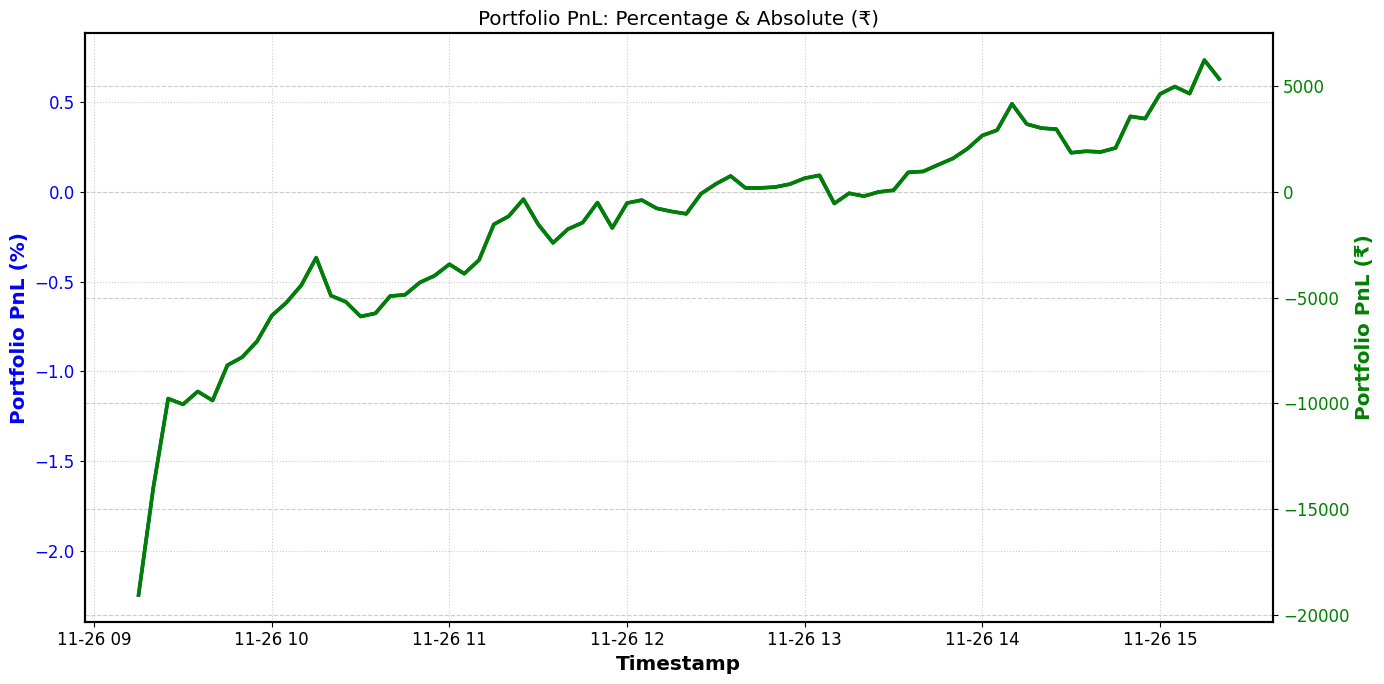

{'portfolio_money_pnl': timestamp
 2025-11-26 09:15:00+05:30   -19051.74
 2025-11-26 09:20:00+05:30   -13967.94
 2025-11-26 09:25:00+05:30    -9769.59
 2025-11-26 09:30:00+05:30   -10043.39
 2025-11-26 09:35:00+05:30    -9432.94
                                ...   
 2025-11-26 15:00:00+05:30     4625.26
 2025-11-26 15:05:00+05:30     4979.11
 2025-11-26 15:10:00+05:30     4645.71
 2025-11-26 15:15:00+05:30     6230.16
 2025-11-26 15:20:00+05:30     5337.86
 Length: 74, dtype: float64}

In [327]:
plot_portfolio_pnl_with_money(mf, trades)

In [311]:
money_pnl

NameError: name 'money_pnl' is not defined

In [155]:
(mf[mf["cumulative_new_low"] < mf["cumulative_new_high"]])


,timestamp,new_high_count,new_low_count,new_high_stocks,new_low_stocks,cumulative_new_high,cumulative_new_low,close_prices,signal,signal_stocks
1,2025-11-14T09:20:00+05:30,2,0,"{BAJFINANCE, SBIN}",{},2,0,"{'BAJFINANCE': 1008.3, 'SBIN': 956.8, 'ICICIBA...",wait,[]
2,2025-11-14T09:25:00+05:30,1,0,{SBIN},{},3,0,"{'BAJFINANCE': 1008.3, 'SBIN': 959.0, 'ICICIBA...",buy,[SBIN]
3,2025-11-14T09:30:00+05:30,2,0,"{SBIN, TCS}",{},5,0,"{'BAJFINANCE': 1008.2, 'SBIN': 960.7, 'ICICIBA...",buy,[SBIN]
4,2025-11-14T09:35:00+05:30,1,0,{SBIN},{},6,0,"{'BAJFINANCE': 1007.9, 'SBIN': 959.7, 'ICICIBA...",wait,[]
5,2025-11-14T09:40:00+05:30,0,0,{},{},6,0,"{'BAJFINANCE': 1007.4, 'SBIN': 960.25, 'ICICIB...",wait,[]
6,2025-11-14T09:45:00+05:30,0,0,{},{},6,0,"{'BAJFINANCE': 1006.9, 'SBIN': 959.3, 'ICICIBA...",wait,[]
7,2025-11-14T09:50:00+05:30,0,0,{},{},6,0,"{'BAJFINANCE': 1003.2, 'SBIN': 958.3, 'ICICIBA...",wait,[]
8,2025-11-14T09:55:00+05:30,0,0,{},{},6,0,"{'BAJFINANCE': 1005.3, 'SBIN': 959.7, 'ICICIBA...",wait,[]
9,2025-11-14T10:00:00+05:30,0,1,{},{ICICIBANK},6,1,"{'BAJFINANCE': 1003.8, 'SBIN': 958.95, 'ICICIB...",sell,[ICICIBANK]
10,2025-11-14T10:05:00+05:30,0,0,{},{},6,1,"{'BAJFINANCE': 1004.5, 'SBIN': 959.2, 'ICICIBA...",wait,[]
